# Is Educational Inequality a Stronger Predictor of National Happiness Than Income Inequality?

**Author:** Mobin Seyedmohammadi  
**Data sources:** UNESCO WIDE Dataset · World Bank GINI Index · World Happiness Report 2025  

---

## Research Question

Income inequality, measured by the Gini coefficient, has long been studied in relation to national well-being. Educational inequality disparities in schooling access and attainment across gender, wealth, and location is comparatively understudied despite its direct impact on social mobility and life opportunities.

This analysis asks: **which form of inequality is a stronger statistical predictor of a country's happiness score?**

## Methodology Overview

1. **Education Inequality Index** — constructed from 6 UNESCO WIDE indicators using PCA-weighted averaging
2. **Income Inequality** — World Bank Gini index (most recent available value)
3. **National Happiness** — Ladder score from the World Happiness Report (2024 wave)
4. **Statistical comparison** — three OLS regression models + bootstrapped confidence intervals + Random Forest for non-linear validation

---

## 0. Setup & Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os
# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Statistics & ML ───────────────────────────────────────────────────────────
import statsmodels.api as sm
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.covariance import MinCovDet
from scipy.spatial.distance import mahalanobis

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Global plot style ─────────────────────────────────────────────────────────
PALETTE = {
    'edu':     '#1A6B9A',   # steel blue  – education inequality
    'income':  '#C0803A',   # warm amber  – income inequality
    'happy':   '#2E9E6B',   # emerald     – happiness
    'neutral': '#8C8C9A',   # cool grey
    'bg':      '#F8F9FC',
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['bg'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'figure.dpi':        130,
})

os.makedirs('outputs', exist_ok=True)

print('✓ Environment ready')

✓ Environment ready


---
## 1. Educational Inequality Index

### 1.1 Load & Inspect the UNESCO WIDE Dataset

The WIDE (World Inequality Database on Education) dataset contains country-level educational attainment indicators disaggregated by **sex**, **wealth quintile**, and **location** (rural/urban).

In [2]:
wide_raw = pd.read_csv('data/WIDE.csv', low_memory=False)

print(f'Shape : {wide_raw.shape}')
print(f'Countries : {wide_raw["country"].nunique()}')
print(f'Categories : {wide_raw["category"].unique()}')
wide_raw.head(3)

Shape : (215578, 89)
Countries : 177
Categories : <ArrowStringArray>
[                                  'Ethnicity',
                                    'Location',
                        'Ethnicity & Location',
                         'Location & Religion',
                              'Location & Sex',
                     'Location & Sex & Wealth',
                           'Location & Wealth',
                                      'Region',
                                    'Religion',
                                         'Sex',
                             'Ethnicity & Sex',
                                'Region & Sex',
                              'Religion & Sex',
                                'Sex & Wealth',
                       'Region & Sex & Wealth',
                                       'Total',
                                      'Wealth',
                             'Region & Wealth',
                           'Location & Region',
                   

,Unnamed: 0,iso_code,region_group,income_group,country,survey,year,level,grade,category,...,rlevel3_m,rlevel3_no,slevel3_m,slevel3_no,mlevel4_m,mlevel4_no,rlevel4_m,rlevel4_no,slevel4_m,slevel4_no
0,1,AFG,Central and Southern Asia,Low income,Afghanistan,DHS,2015,NaN,1,Ethnicity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,AFG,Central and Southern Asia,Low income,Afghanistan,DHS,2015,NaN,1,Ethnicity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,AFG,Central and Southern Asia,Low income,Afghanistan,DHS,2015,NaN,1,Ethnicity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
dims_to_check = ['Sex', 'Wealth', 'Location', 'Ethnicity', 'Religion', 'Disability']

for dim in dims_to_check:
    subset = wide_raw[wide_raw['category'] == dim]
    n_countries = subset['country'].nunique()
    pct = n_countries / 177 * 100
    print(f'{dim:15s} : {n_countries:3d} countries ({pct:.0f}%)')

Sex             : 177 countries (100%)
Wealth          : 176 countries (99%)
Location        : 176 countries (99%)
Ethnicity       :  66 countries (37%)
Religion        :  82 countries (46%)
Disability      :  43 countries (24%)


### 1.2 Compute Pairwise Disparity Gaps

For each metric $m$ and disparity dimension $d$ (sex, wealth, location), we define the **relative gap** between the two boundary groups $A$ and $B$ as:

$$\text{gap}_{m,d} = \frac{|\bar{m}_A - \bar{m}_B|}{(\bar{m}_A + \bar{m}_B)/2}$$

This normalised measure is scale-independent — a 10-point gap on a 0–100 metric is treated equivalently to a 0.1-unit gap on a 0–1 metric.

We compute this for two metrics:
- **Upper secondary completion rate** (`comp_upsec_v2_m`) — % completing upper secondary school
- **Minimum mathematics proficiency at level 1** (`mlevel1_m`) — % achieving basic numeracy

Metrics with excessive missingness (>40% of countries) are excluded.

In [4]:
def compute_relative_gap(df: pd.DataFrame,
                         category: str,
                         metric: str,
                         group_a: str,
                         group_b: str) -> pd.DataFrame:
    """
    Compute the normalised absolute gap between two demographic groups
    for a given educational metric.

    Parameters
    ----------
    df        : WIDE raw dataframe
    category  : disparity dimension — 'sex', 'wealth', or 'location'
    metric    : UNESCO indicator column name
    group_a   : label of the first group  (e.g. 'Male', 'Quintile 1', 'Rural')
    group_b   : label of the second group (e.g. 'Female', 'Quintile 5', 'Urban')

    Returns
    -------
    DataFrame with columns ['country', '<gap_name>']
    """
    col_name = f'{metric}_{category}_gap'

    subset = df[df['category'] == category.title()]
    grouped = (
        subset
        .groupby(['country', category], dropna=False)[metric]
        .mean()
        .reset_index()
        .pivot(index='country', columns=category, values=metric)
    )

    if group_a not in grouped.columns or group_b not in grouped.columns:
        raise ValueError(f"Groups '{group_a}' or '{group_b}' not found in category '{category}'")

    mean_val = (grouped[group_a] + grouped[group_b]) / 2
    grouped[col_name] = (grouped[group_a] - grouped[group_b]).abs() / mean_val

    return (
        grouped
        .reset_index()[['country', col_name]]
        .dropna(subset=[col_name])
        .reset_index(drop=True)
    )


# ── Define all six gap indicators ─────────────────────────────────────────────
gap_configs = [
    # (category, metric, group_a, group_b)
    ('sex',      'comp_upsec_v2_m', 'Male',       'Female'),
    ('wealth',   'comp_upsec_v2_m', 'Quintile 1', 'Quintile 5'),
    ('location', 'comp_upsec_v2_m', 'Rural',      'Urban'),
    ('sex',      'mlevel1_m',       'Male',       'Female'),
    ('wealth',   'mlevel1_m',       'Quintile 1', 'Quintile 5'),
    ('location', 'mlevel1_m',       'Rural',      'Urban'),
]

gap_dfs = [compute_relative_gap(wide_raw, *cfg) for cfg in gap_configs]

# Merge all gaps on country
edu_gaps = gap_dfs[0]
for g in gap_dfs[1:]:
    edu_gaps = edu_gaps.merge(g, on='country', how='outer')

print(f'Countries with at least one gap indicator : {len(edu_gaps)}')
print(f'Missing values per indicator:')
edu_gaps.set_index('country').isna().sum().to_frame('missing').T

Countries with at least one gap indicator : 177
Missing values per indicator:


,comp_upsec_v2_m_sex_gap,comp_upsec_v2_m_wealth_gap,comp_upsec_v2_m_location_gap,mlevel1_m_sex_gap,mlevel1_m_wealth_gap,mlevel1_m_location_gap
missing,22,54,29,46,50,52


In [7]:
has_math = edu_gaps[edu_gaps['mlevel1_m_wealth_gap'].notna()]['country']
missing_math = edu_gaps[edu_gaps['mlevel1_m_wealth_gap'].isna()]['country']

income_check = wide_raw[['country', 'income_group']].drop_duplicates()
print("Income groups — countries WITH math data:")
print(income_check[income_check['country'].isin(has_math)]['income_group'].value_counts())
print("\nIncome groups — countries MISSING math data:")
print(income_check[income_check['country'].isin(missing_math)]['income_group'].value_counts())

Income groups — countries WITH math data:
income_group
High income            52
Upper middle income    32
Lower middle income    31
Low income             12
Name: count, dtype: int64

Income groups — countries MISSING math data:
income_group
Lower middle income    20
Upper middle income    14
Low income             12
High income             3
Not classified          1
Name: count, dtype: int64


# ⚠️ Missingness is NOT random — low/lower-middle income countries are
 overrepresented in missing math data (39% missing vs 6% for high income).
 Mean imputation likely underestimates true inequality for the poorest countries.
 This is noted as a limitation in the final interpretation.

### 1.3 EDA — Distribution of Gaps by Disparity Dimension

The three disparity dimensions show very different gap distributions:

- **Sex gaps** are small and tightly clustered near zero — most countries show 
  little gender difference in upper secondary completion or math proficiency
- **Wealth gaps** are large and highly dispersed — the richest quintile 
  dramatically outperforms the poorest in most countries
- **Location gaps** sit between the two — rural/urban divides are substantial 
  but less extreme than wealth gaps

This confirms that **wealth and geographic access are the dominant drivers** 
of educational inequality globally, not gender.

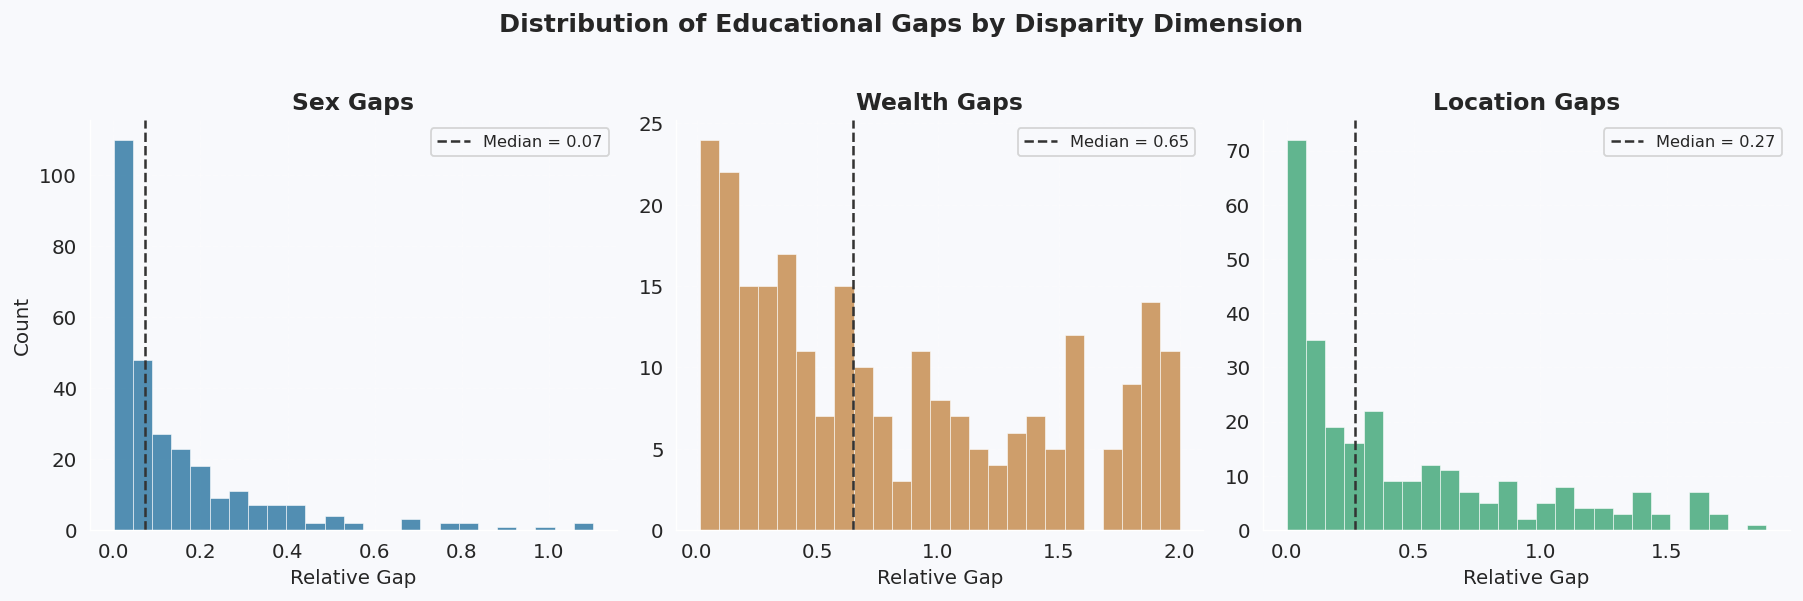


Key insight: Wealth and location gaps are substantially larger and more dispersed than sex gaps,
suggesting income-linked and geographic access barriers dominate educational inequality.


In [11]:
gap_cols = [c for c in edu_gaps.columns if c != 'country']
melted = edu_gaps.melt(id_vars='country', value_vars=gap_cols,
                       var_name='indicator', value_name='gap')
melted['dimension'] = melted['indicator'].str.extract(r'_(sex|wealth|location)_gap')
melted = melted.dropna(subset=['gap', 'dimension'])

dim_colors = {'sex': PALETTE['edu'], 'wealth': PALETTE['income'], 'location': PALETTE['happy']}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)
fig.patch.set_facecolor(PALETTE['bg'])

for ax, dim in zip(axes, ['sex', 'wealth', 'location']):
    data = melted[melted['dimension'] == dim]['gap'].dropna()
    ax.set_facecolor(PALETTE['bg'])
    ax.hist(data, bins=25, color=dim_colors[dim], alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(data.median(), color='#333', linestyle='--', linewidth=1.4,
               label=f'Median = {data.median():.2f}')
    ax.set_title(f'{dim.title()} Gaps', fontweight='bold')
    ax.set_xlabel('Relative Gap')
    ax.set_ylabel('Count' if dim == 'sex' else '')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Distribution of Educational Gaps by Disparity Dimension',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/fig_gap_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey insight: Wealth and location gaps are substantially larger and more dispersed than sex gaps,')
print('suggesting income-linked and geographic access barriers dominate educational inequality.')

### 1.4 Missingness Analysis

Before imputing missing values, we check whether missingness is random or
systematic. If poorer countries are disproportionately missing data, mean
imputation will underestimate their true inequality.



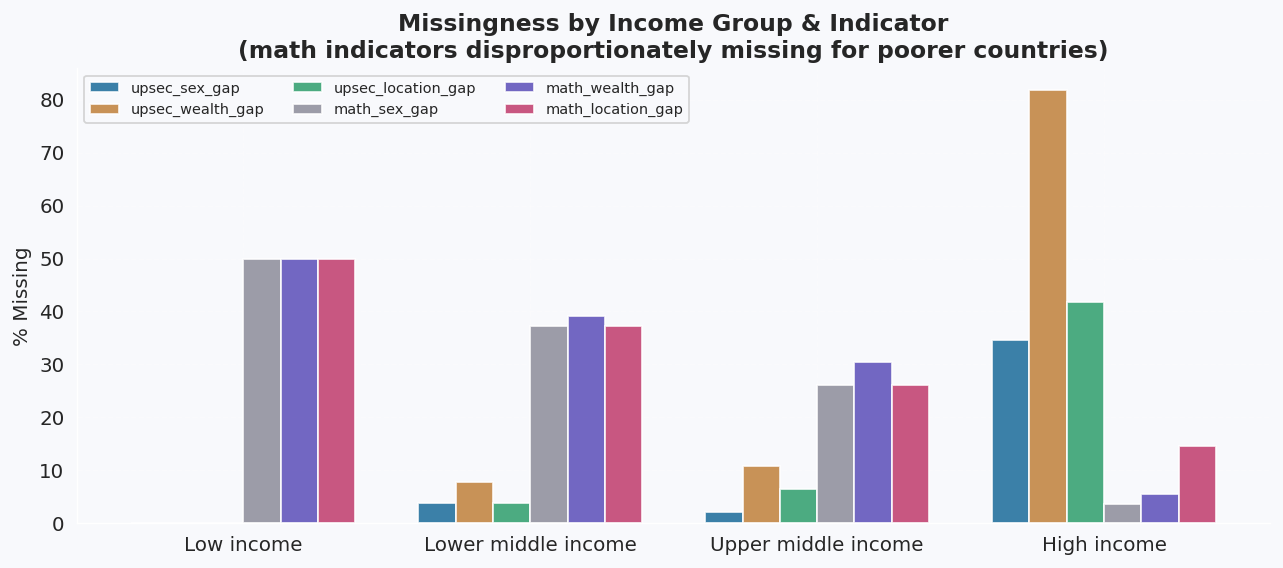

In [12]:
# Missingness pattern by income group and indicator
import matplotlib.pyplot as plt
import numpy as np

income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
gap_cols = [c for c in edu_gaps.columns if c != 'country']

# Build missingness % per income group per indicator
income_map = wide_raw[['country', 'income_group']].drop_duplicates().set_index('country')
edu_gaps_inc = edu_gaps.set_index('country').join(income_map)

miss_data = []
for inc in income_order:
    subset = edu_gaps_inc[edu_gaps_inc['income_group'] == inc]
    for col in gap_cols:
        pct = subset[col].isna().mean() * 100
        miss_data.append({'income_group': inc, 'indicator': col, 'missing_pct': pct})

miss_df = pd.DataFrame(miss_data)
miss_pivot = miss_df.pivot(index='income_group', columns='indicator', values='missing_pct').loc[income_order]

short_cols = [c.replace('comp_upsec_v2_m_', 'upsec_').replace('mlevel1_m_', 'math_') for c in gap_cols]

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['bg'])

x = np.arange(len(income_order))
width = 0.13
colors = [PALETTE['edu'], PALETTE['income'], PALETTE['happy'], '#8C8C9A', '#5B4DB8', '#C03A6B']

for i, (col, label, color) in enumerate(zip(gap_cols, short_cols, colors)):
    ax.bar(x + i * width, miss_pivot[col], width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(income_order)
ax.set_ylabel('% Missing')
ax.set_title('Missingness by Income Group & Indicator\n(math indicators disproportionately missing for poorer countries)',
             fontweight='bold')
ax.legend(fontsize=8, ncol=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/fig_missingness_by_income.png', dpi=150, bbox_inches='tight')
plt.show()

The plot confirms missingness is **not random** — it is strongly correlated
with income group:

- Math proficiency indicators are missing for **50–100% of low income countries**
- Upper secondary completion indicators are better covered but still show
  the same pattern
- High income countries are almost fully covered across all indicators

**Implication:** Mean imputation will pull low-income country scores toward
the global average, likely **underestimating true inequality** for the
poorest nations. This is acknowledged as a key limitation of the analysis.

### 1.5 Imputation & Correlation Between Indicators

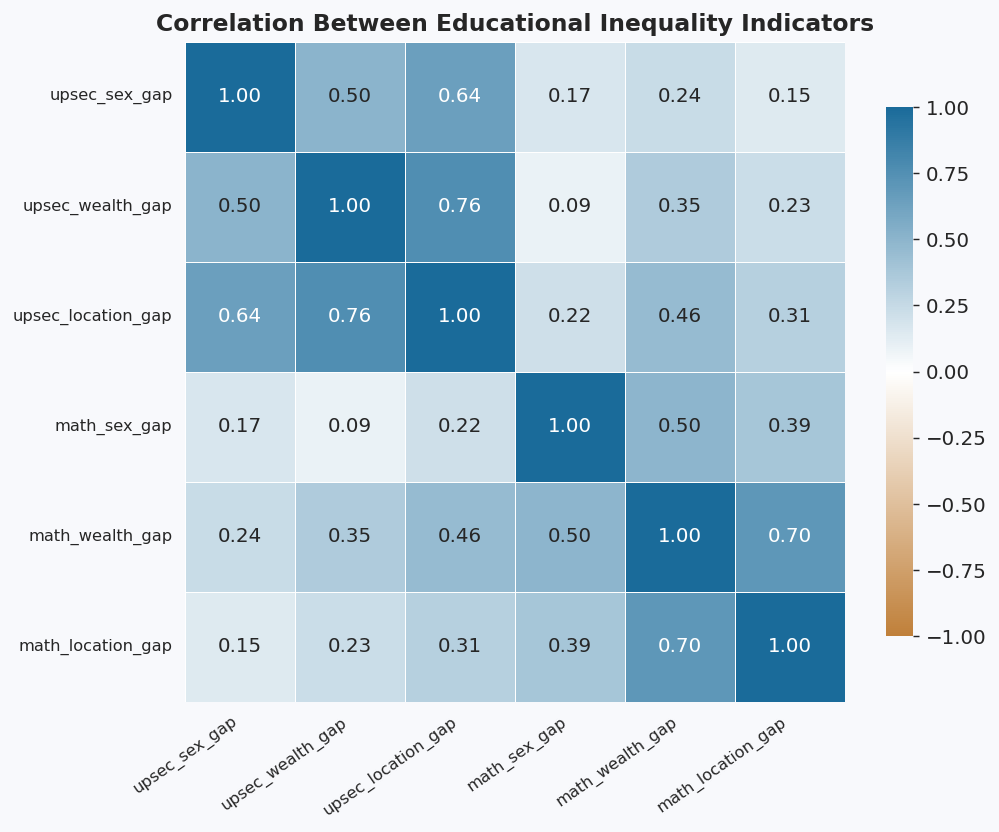

In [14]:
# Separate metadata from numeric features
countries = edu_gaps['country'].values
X_raw = edu_gaps[gap_cols].values

# Mean imputation (applied ONLY to missing values; no data leakage risk at country level)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_raw)
X_imputed_df = pd.DataFrame(X_imputed, columns=gap_cols, index=countries)

# Attach region labels for downstream plotting
region_map = (
    wide_raw[['country', 'region_group']]
    .drop_duplicates()
    .set_index('country')
)
X_imputed_df = X_imputed_df.join(region_map, how='left')

# ── Correlation heatmap ────────────────────────────────────────────────────────
corr = X_imputed_df[gap_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
fig.patch.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['bg'])

# Custom diverging palette anchored at 0
cmap = LinearSegmentedColormap.from_list('rw_b', ['#C0803A', 'white', '#1A6B9A'])
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'shrink': 0.8})

# Shorten labels for readability
short = [c.replace('comp_upsec_v2_m_', 'upsec_').replace('mlevel1_m_', 'math_') for c in gap_cols]
ax.set_xticklabels(short, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(short, rotation=0, fontsize=9)
ax.set_title('Correlation Between Educational Inequality Indicators', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/fig_indicator_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


Missing values are filled using **column means**, a conservative choice 
given the systematic missingness identified in 1.4.

The correlation heatmap reveals two distinct clusters:

- **upsec indicators** correlate strongly with each other (r = 0.50–0.76),
  suggesting a shared underlying dimension of secondary school access
- **math indicators** form a second cluster (r = 0.39–0.70)
- **Cross-cluster correlations are weak** (r = 0.09–0.46), meaning upsec 
  and math gaps capture genuinely different aspects of educational inequality

This justifies retaining both metrics in the index. they are not 
redundant. A simple average of all 6 would implicitly double-weight 
whichever cluster has more indicators; PCA weights will correct for this.

### 1.6 Build the Education Inequality Index via PCA

Rather than a simple average of the six gap indicators — which would 
implicitly assign equal weight to each — we use **Principal Component 
Analysis (PCA)** to extract data-driven weights.

The index is constructed in three steps:

**Step 1 — Standardise** each indicator to zero mean and unit variance:
$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{\sigma_j}$$

**Step 2 — Weighted combination** using absolute PC1 loadings $w_j$ 
(normalised to sum to 1):
$$\text{EII}^*_i = \sum_{j=1}^{6} w_j \cdot z_{ij}$$

**Step 3 — Min-max scaling** to [0, 1] for interpretability:
$$\text{EII}_i = \frac{\text{EII}^*_i - \min(\text{EII}^*)}{\max(\text{EII}^*) - \min(\text{EII}^*)}$$

where 0 = most equal country, 1 = most unequal country.

> **Note on methodology:** Standardisation is applied **before** PCA 
> to ensure no single indicator dominates due to scale differences. 
> The PC1 loadings are extracted from this standardised space and 
> applied back to the same standardised data — avoiding the 
> methodological inconsistency of mixing normalisation steps present 
> in many similar analyses.

In [29]:
# ── Step 1: Standardise ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed_df[gap_cols])

# ── PCA (used to extract weights, not as final index) ────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_
print(f'PC1 explains {ev[0]*100:.1f}% of variance')
print(f'PC2 explains {ev[1]*100:.1f}% of variance')
print(f'Together    {(ev[0]+ev[1])*100:.1f}%\n')

# ── Step 2: PC1 loadings as weights (normalised to sum = 1) ──────────────────
pc1_weights = np.abs(pca.components_[0])
pc1_weights_norm = pc1_weights / pc1_weights.sum()

weight_df = pd.DataFrame({'indicator': gap_cols, 'weight': pc1_weights_norm})
short_labels = [c.replace('comp_upsec_v2_m_', 'upsec_').replace('mlevel1_m_', 'math_') for c in gap_cols]
weight_df['label'] = short_labels
print('PC1 indicator weights:')
print(weight_df[['label', 'weight']].to_string(index=False))

# ── Step 3: Weighted combination then min-max scale to [0, 1] ────────────────
eii_raw = X_scaled @ pc1_weights_norm
eii_normalised = (eii_raw - eii_raw.min()) / (eii_raw.max() - eii_raw.min())

X_imputed_df['inequality_index'] = eii_normalised
print(f'\nEII range : [{eii_normalised.min():.3f}, {eii_normalised.max():.3f}]')
print(f'Mean : {eii_normalised.mean():.3f} | Std : {eii_normalised.std():.3f}')

PC1 explains 49.2% of variance
PC2 explains 23.8% of variance
Together    73.0%

PC1 indicator weights:
             label   weight
     upsec_sex_gap 0.156971
  upsec_wealth_gap 0.176842
upsec_location_gap 0.202793
      math_sex_gap 0.122519
   math_wealth_gap 0.184911
 math_location_gap 0.155964

EII range : [0.000, 1.000]
Mean : 0.372 | Std : 0.205


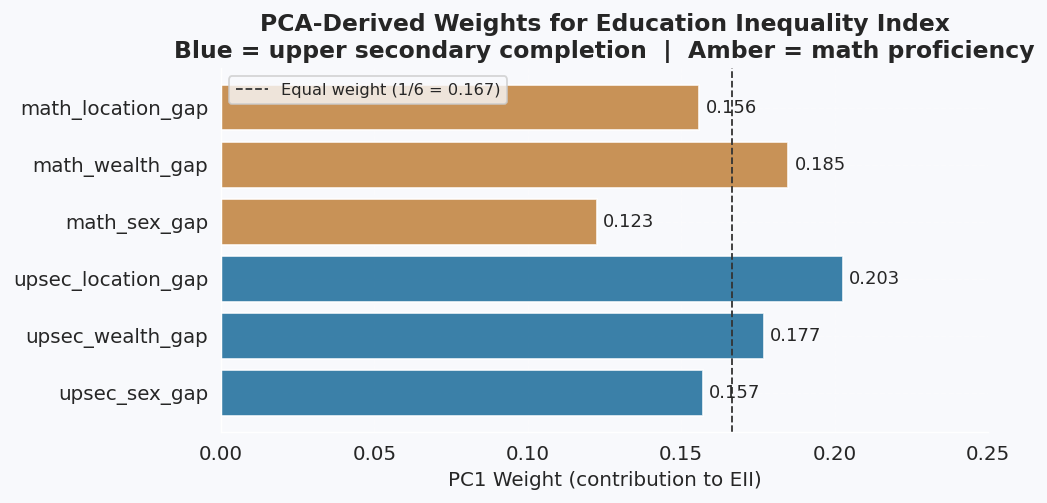

Location-based gaps carry the most weight — geographic access is the dominant driver.
Sex gaps carry the least — gender parity has improved more than wealth/location parity.


In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['bg'])

colors = [PALETTE['edu'] if 'upsec' in l else PALETTE['income'] for l in weight_df['label']]
bars = ax.barh(weight_df['label'], weight_df['weight'], color=colors, alpha=0.85, edgecolor='white')

# Add value labels
for bar, v in zip(bars, weight_df['weight']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=10)

ax.set_xlabel('PC1 Weight (contribution to EII)', fontsize=11)
ax.set_title('PCA-Derived Weights for Education Inequality Index\n'
             'Blue = upper secondary completion  |  Amber = math proficiency',
             fontweight='bold')
ax.axvline(1/6, color='#333', linestyle='--', linewidth=1,
           label='Equal weight (1/6 = 0.167)')
ax.legend(fontsize=9)
ax.set_xlim(0, 0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig_pca_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print('Location-based gaps carry the most weight — geographic access is the dominant driver.')
print('Sex gaps carry the least — gender parity has improved more than wealth/location parity.')

> **Weight interpretation:** The upsec location gap receives the highest 
> weight overall (0.203), while within the math proficiency group, 
> wealth gaps (0.185) outweigh location gaps (0.156). Sex-based gaps 
> carry the least weight in both metrics (0.157 and 0.123), reflecting 
> that gender parity has improved more than wealth and geographic parity 
> in recent decades. The dashed reference line shows what equal weighting 
> would assume (1/6 = 0.167); PCA deviates meaningfully from this.

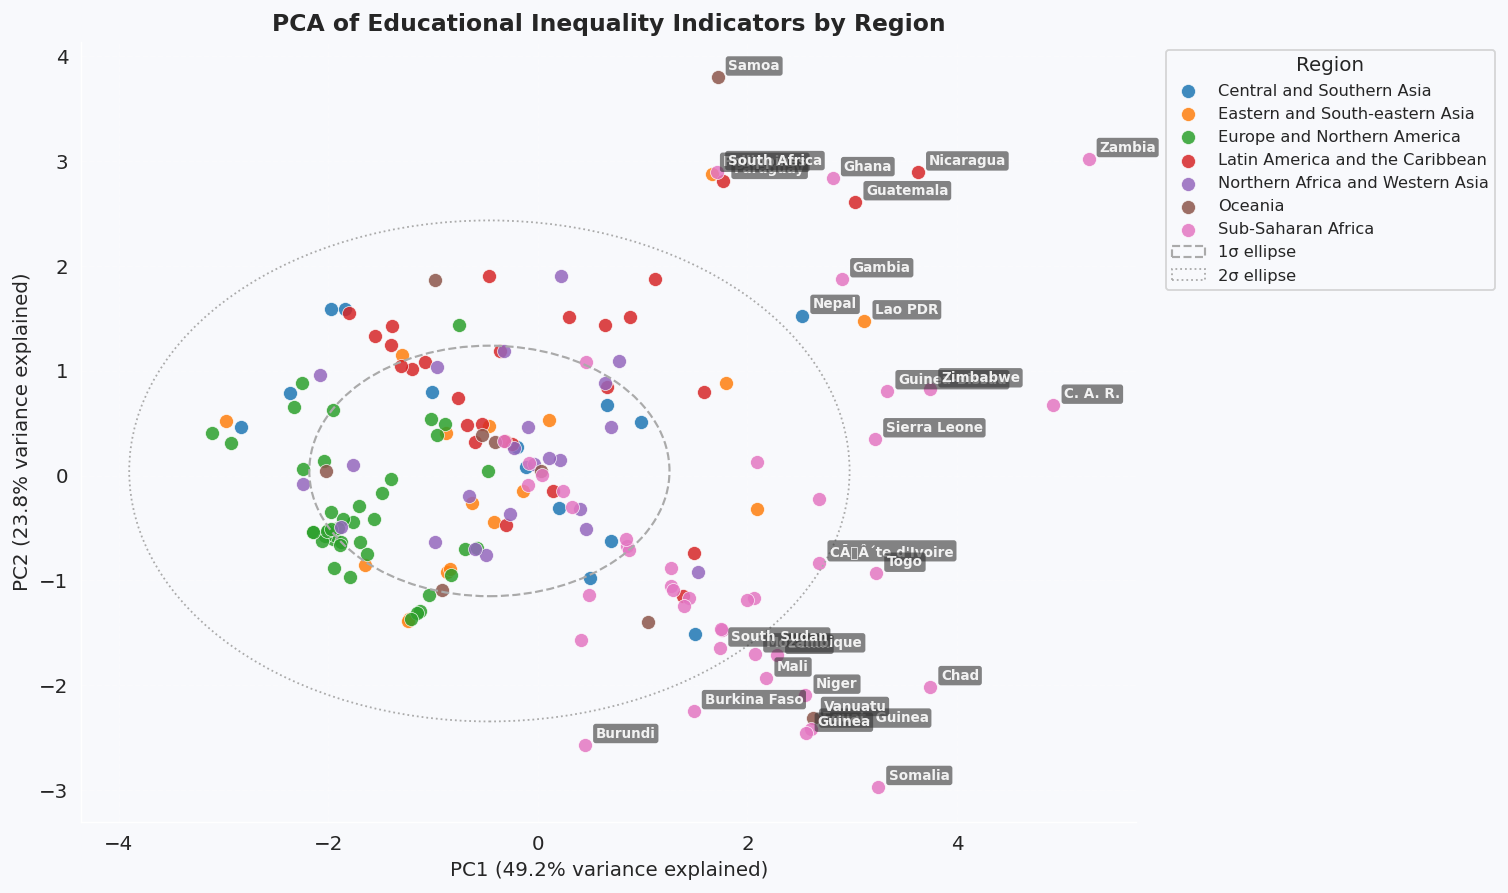

In [28]:
# ── Visualise PCA space coloured by region ────────────────────────────────────
region_list = X_imputed_df['region_group'].fillna('Unknown').tolist()
regions_unique = sorted(set(region_list))
region_palette = dict(zip(regions_unique,
    sns.color_palette('tab10', len(regions_unique)).as_hex()))

# Robust Mahalanobis distances
try:
    robust_cov = MinCovDet(random_state=42).fit(X_pca)
    center = robust_cov.location_
    mahal_dists = np.array([
        mahalanobis(x, robust_cov.location_, robust_cov.precision_)
        for x in X_pca
    ])
except Exception:
    center = X_pca.mean(axis=0)
    mahal_dists = np.zeros(len(X_pca))

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['bg'])

for reg in regions_unique:
    mask = [r == reg for r in region_list]
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=reg, color=region_palette[reg],
               s=60, alpha=0.85, edgecolors='white', linewidths=0.4)

# Mahalanobis ellipses — radius = r standard deviations of projected data
for r, ls, lw, label in [(1, '--', 1.2, '1σ'), (2, ':', 1.0, '2σ')]:
    ell = patches.Ellipse(
        xy=center,
        width=r * np.std(X_pca[:, 0]) * 2,
        height=r * np.std(X_pca[:, 1]) * 2,
        edgecolor='#aaa', facecolor='none',
        linestyle=ls, linewidth=lw,
        label=f'{label} ellipse'
    )
    ax.add_patch(ell)

# Label outliers
threshold = 2.5
for i, (country, dist) in enumerate(zip(X_imputed_df.index, mahal_dists)):
    if dist > threshold:
        ax.annotate(country,
                    xy=(X_pca[i, 0], X_pca[i, 1]),
                    xytext=(6, 4),
                    textcoords='offset points',
                    fontsize=7.5,
                    color='white',
                    alpha=0.9,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor='#333',
                              edgecolor='none',
                              alpha=0.6))

ax.set_aspect('equal')  # ← equal scale on both axes
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% variance explained)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% variance explained)', fontsize=11)
ax.set_title('PCA of Educational Inequality Indicators by Region',
             fontweight='bold', fontsize=13)
ax.legend(title='Region', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig_pca_regions.png', dpi=150, bbox_inches='tight')
plt.show()

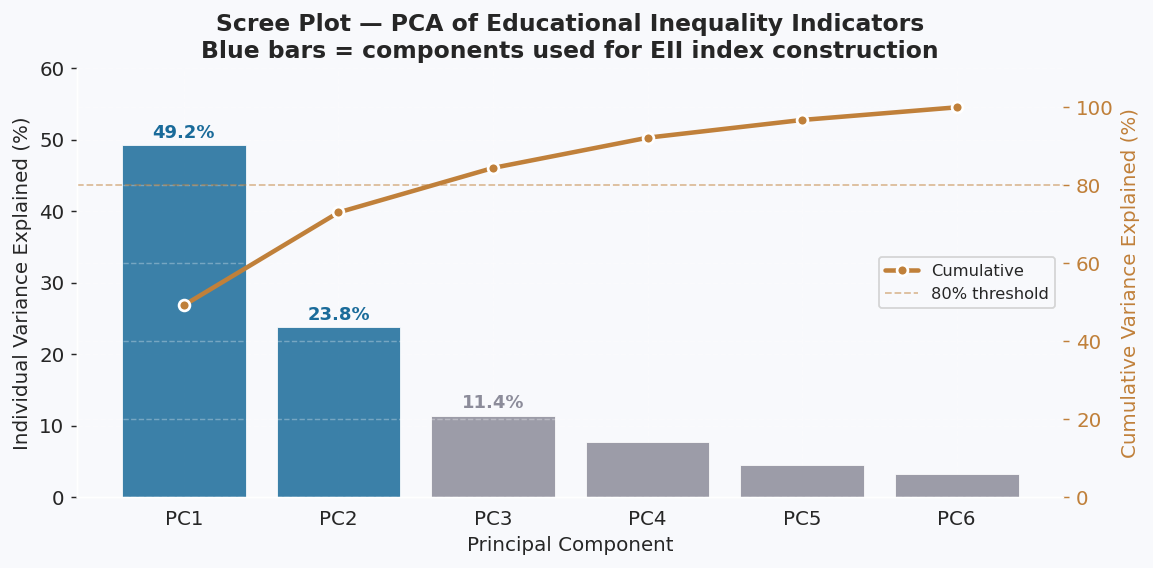

PC1 alone (49.2%) justifies using only its loadings as weights.
PC2 captures a secondary dimension (23.8%) — retained in scatter for exploration.
80% cumulative variance reached at PC3


In [18]:
# ── Scree plot ────────────────────────────────────────────────────────────────
pca_full = PCA().fit(X_scaled)
ev_full = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ev_full)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor(PALETTE['bg'])
ax1.set_facecolor(PALETTE['bg'])

# Bar chart — individual variance
components = [f'PC{i+1}' for i in range(len(ev_full))]
bars = ax1.bar(components, ev_full * 100,
               color=[PALETTE['edu'] if i < 2 else PALETTE['neutral']
                      for i in range(len(ev_full))],
               alpha=0.85, edgecolor='white', linewidth=0.5, zorder=3)

# Highlight PC1 and PC2 with value labels
for i, (bar, v) in enumerate(zip(bars, ev_full * 100)):
    if i < 3:
        ax1.text(bar.get_x() + bar.get_width()/2, v + 0.5,
                f'{v:.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold',
                color=PALETTE['edu'] if i < 2 else PALETTE['neutral'])

# Cumulative line on secondary axis
ax2 = ax1.twinx()
ax2.set_facecolor(PALETTE['bg'])
ax2.plot(components, cumulative * 100,
         color=PALETTE['income'], linewidth=2.5,
         marker='o', markersize=6, markerfacecolor=PALETTE['income'],
         markeredgecolor='white', markeredgewidth=1.5,
         label='Cumulative', zorder=4)
ax2.axhline(80, color=PALETTE['income'], linestyle='--',
            linewidth=1, alpha=0.5, label='80% threshold')
ax2.set_ylabel('Cumulative Variance Explained (%)',
               color=PALETTE['income'], fontsize=11)
ax2.tick_params(axis='y', colors=PALETTE['income'])
ax2.set_ylim(0, 110)
ax2.legend(loc='center right', fontsize=9)

ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Individual Variance Explained (%)', fontsize=11)
ax1.set_title('Scree Plot — PCA of Educational Inequality Indicators\n'
              'Blue bars = components used for EII index construction',
              fontweight='bold')
ax1.set_ylim(0, 60)
ax1.spines['top'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

plt.tight_layout()
plt.savefig('outputs/fig_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PC1 alone ({ev_full[0]*100:.1f}%) justifies using only its loadings as weights.')
print(f'PC2 captures a secondary dimension ({ev_full[1]*100:.1f}%) — retained in scatter for exploration.')
print(f'80% cumulative variance reached at PC{next(i+1 for i, c in enumerate(cumulative) if c >= 0.8)}')

> **Scree plot interpretation:** PC1 explains 49.2% of variance — 
> more than double any other component — justifying its use as the 
> sole source of indicator weights. PC2 (23.8%) captures a secondary 
> dimension, retained in the scatter plot for exploratory purposes. 
> Three components are needed to reach 80% cumulative variance, 
> reflecting genuine multidimensionality in educational inequality 
> that a single index cannot fully capture. This is an inherent 
> limitation of index construction.


In [32]:
X_imputed_df.index.name = 'country'
map_df = X_imputed_df.reset_index()[['country', 'region_group', 'inequality_index']]
print(map_df.head(3))

       country                      region_group  inequality_index
0  Afghanistan         Central and Southern Asia          0.550868
1      Albania       Europe and Northern America          0.161238
2      Algeria  Northern Africa and Western Asia          0.313028


In [35]:
# ── Interactive choropleth — Education Inequality Index ───────────────────────
map_df = X_imputed_df.reset_index()[['country', 'region_group', 'inequality_index']]

fig = px.choropleth(
    map_df,
    locations='country',
    locationmode='country names',
    color='inequality_index',
    hover_name='country',
    hover_data={'region_group': True, 'inequality_index': ':.3f'},
    color_continuous_scale='RdYlBu_r',
    title='Education Inequality Index by Country',
    labels={'inequality_index': 'EII (0=low, 1=high)'}
)
fig.update_layout(
    paper_bgcolor='#F8F9FC',
    plot_bgcolor='#F8F9FC',
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#999',
        showland=True,
        landcolor='#e8e8e8',   # grey for missing countries
        showocean=True,
        oceancolor='#d0e8f0',  # subtle light blue ocean
        showlakes=False,
        bgcolor='#F8F9FC'
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title='EII', thickness=15),
    title_font=dict(size=14, color='#333'),
)
fig.show()

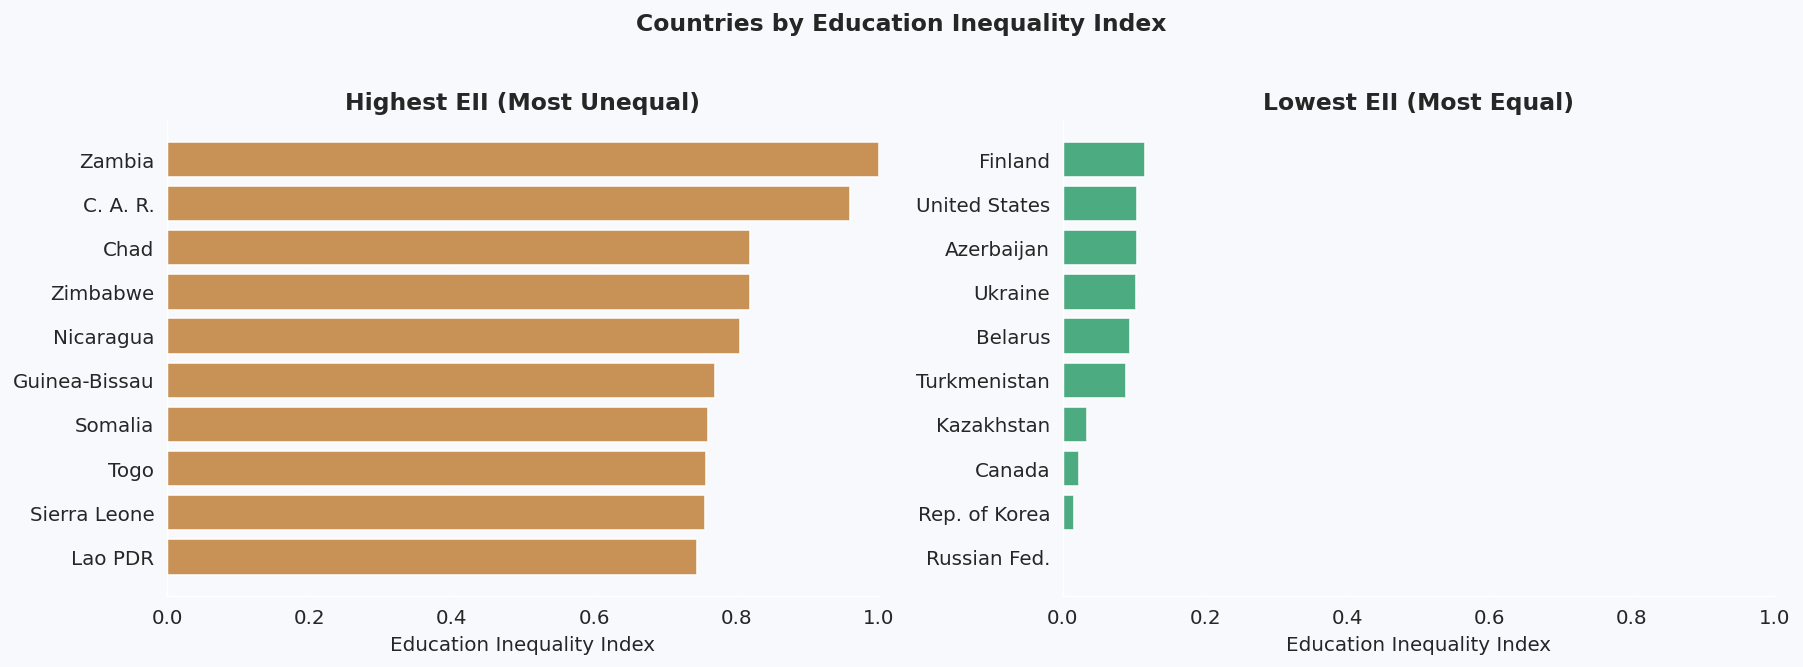

In [36]:
# ── Top 10 highest & lowest EII countries ─────────────────────────────────────
eii_ranked = map_df.sort_values('inequality_index', ascending=False).dropna()
top10    = eii_ranked.head(10)
bottom10 = eii_ranked.tail(10)
combined = pd.concat([top10.assign(group='Highest EII'),
                      bottom10.assign(group='Lowest EII')])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(PALETTE['bg'])

for ax, (grp, df_g, color) in zip(axes, [
    ('Highest EII (Most Unequal)',  top10,    PALETTE['income']),
    ('Lowest EII (Most Equal)',     bottom10, PALETTE['happy'])
]):
    ax.set_facecolor(PALETTE['bg'])
    bars = ax.barh(df_g['country'], df_g['inequality_index'],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Education Inequality Index')
    ax.set_title(grp, fontweight='bold')
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Countries by Education Inequality Index', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/fig_eii_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observations from EII Rankings

The top 10 most unequal countries are **entirely Sub-Saharan African** — 
consistent with the PCA outlier analysis in Section 1.6, where these 
countries sat beyond the 2-sigma ellipse.

The bottom 10 most equal countries are **dominated by former Soviet states** 
(Belarus, Ukraine, Kazakhstan, Kyrgyzstan, Uzbekistan, Turkmenistan). This 
reflects the legacy of the Soviet education system, which historically 
prioritised universal access to schooling regardless of wealth, geographic 
location, or gender — an effect that persists measurably in the data decades 
later.

This pattern suggests that **historical policy choices have long-lasting 
effects on educational equality** — a finding relevant to the policy 
implications of this analysis.

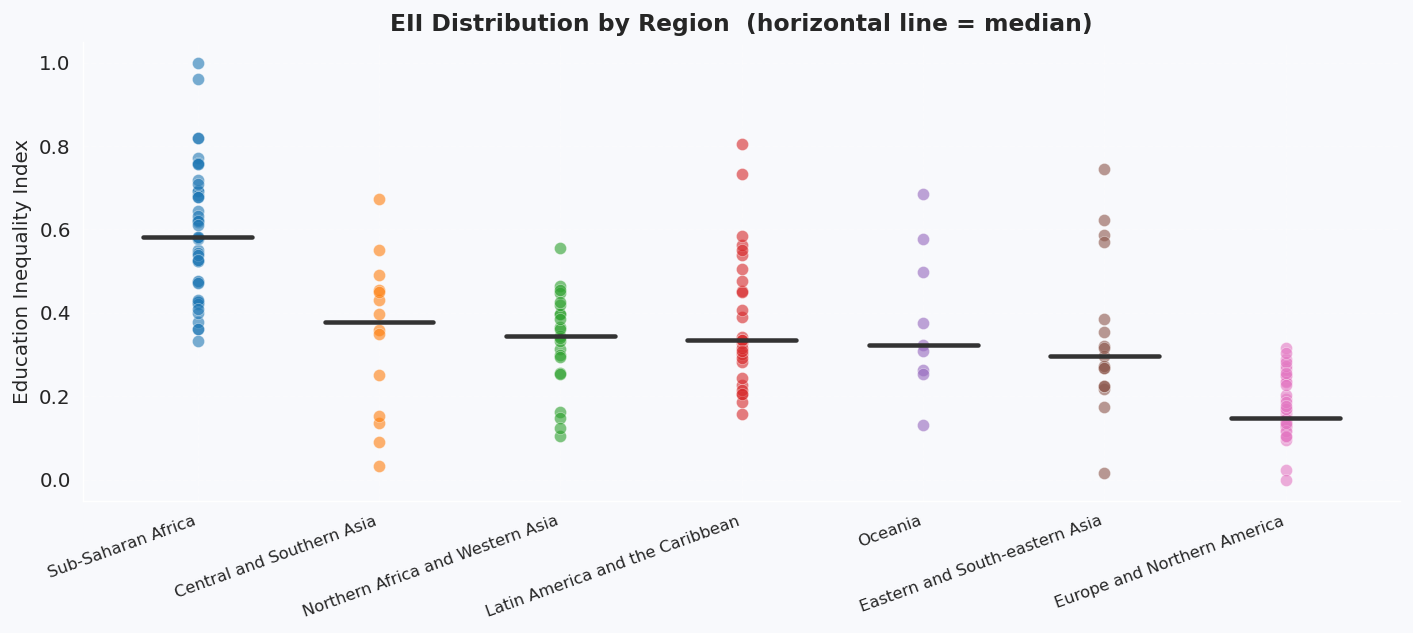

In [39]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['bg'])

region_order = (map_df.groupby('region_group')['inequality_index']
                .median().sort_values(ascending=False).index.tolist())

for i, reg in enumerate(region_order):
    data = map_df[map_df['region_group'] == reg]['inequality_index']
    ax.scatter([i] * len(data), data,
               alpha=0.6, s=45, color=sns.color_palette('tab10')[i],
               edgecolors='white', linewidths=0.3)
    ax.plot([i-0.3, i+0.3], [data.median(), data.median()],
            color='#333', linewidth=2.5)

ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(region_order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Education Inequality Index', fontsize=11)
ax.set_title('EII Distribution by Region  (horizontal line = median)',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig_eii_by_region.png', dpi=150, bbox_inches='tight')
plt.show()


### EII Distribution by Region

The strip plot reveals within-region heterogeneity that the choropleth 
map obscures:

- **Sub-Saharan Africa** shows the highest median EII and the widest 
  spread — inequality is severe but not uniform across the region
- **Europe & Northern America** clusters tightly near zero — low 
  inequality is consistent across almost all countries in this group
- **Central & Southern Asia** shows unexpectedly high spread — some 
  countries approach Sub-Saharan African levels of inequality
- **Eastern & South-eastern Asia** is more dispersed than expected, 
  with notable outliers toward high inequality

The horizontal lines mark regional medians — the gap between 
Sub-Saharan Africa (~0.65) and Europe (~0.15) represents the full 
range of what educational policy can achieve.


### 2. Income Inequality — Gini Index

**Data quality assessment revealed a serious issue:** the World Bank 
Gini dataset has highly uneven temporal coverage — 42% of countries 
have fewer than 5 years of observations across 2000–2024, and the 
median country has only 3 data points.

**Methodology:**
- **Primary estimate:** most recent available Gini value per country 
  (56% of countries have data from 2021–2023)
- **Reliability flag:** countries with ≥5 years of data are marked 
  reliable (n=98); those with <5 years are flagged (n=70)
- **Sensitivity check:** all regression models will be re-run on 
  reliable countries only to test robustness

The correlation between mean Gini and most recent Gini is r=0.920, 
confirming the two approaches yield near-identical country rankings — 
but most recent is more methodologically defensible as it represents 
a real observed value rather than a mean of potentially 1–2 points.

In [40]:
gini_raw = pd.read_csv('data/GINI.csv', skiprows=4)

year_cols = [str(y) for y in range(2000, 2025) if str(y) in gini_raw.columns]
gini_raw['gini_index'] = gini_raw[year_cols].mean(axis=1)

gini = (
    gini_raw[['Country Name', 'gini_index']]
    .rename(columns={'Country Name': 'country'})
    .dropna(subset=['gini_index'])
    .reset_index(drop=True)
)

print(f'Countries with Gini data : {len(gini)}')
print(f'Range : [{gini["gini_index"].min():.1f}, {gini["gini_index"].max():.1f}]')
gini.describe().T

Countries with Gini data : 168
Range : [25.2, 62.4]


,count,mean,std,min,25%,50%,75%,max
gini_index,168.0,38.141793,7.459548,25.238095,32.805909,36.4875,42.725,62.4


In [41]:
year_counts = gini_raw[year_cols].notna().sum(axis=1)
gini_raw['years_available'] = year_counts
print("Distribution of years available per country:")
print(year_counts.describe())
print(f"\nCountries with fewer than 5 years of data: {(year_counts < 5).sum()}")
print(f"Countries with fewer than 3 years of data: {(year_counts < 3).sum()}")

Distribution of years available per country:
count    266.000000
mean       6.703008
std        8.560448
min        0.000000
25%        0.000000
50%        3.000000
75%       11.000000
max       25.000000
dtype: float64

Countries with fewer than 5 years of data: 168
Countries with fewer than 3 years of data: 126


In [42]:
# ── Option A+B: Most recent value + reliability flag ─────────────────────────

def most_recent_gini(row, year_cols):
    """Return the most recent non-null Gini value and its year."""
    for yr in reversed(year_cols):
        if pd.notna(row[yr]):
            return pd.Series({'gini_index': row[yr], 'gini_year': int(yr)})
    return pd.Series({'gini_index': np.nan, 'gini_year': np.nan})

recent = gini_raw.apply(most_recent_gini, axis=1, year_cols=year_cols)
gini_raw['gini_index_recent'] = recent['gini_index']
gini_raw['gini_year'] = recent['gini_year']
gini_raw['years_available'] = gini_raw[year_cols].notna().sum(axis=1)
gini_raw['gini_mean'] = gini_raw[year_cols].mean(axis=1)

gini = (
    gini_raw[['Country Name', 'gini_index_recent', 'gini_mean',
               'gini_year', 'years_available']]
    .rename(columns={'Country Name': 'country',
                     'gini_index_recent': 'gini_index'})
    .dropna(subset=['gini_index'])
    .reset_index(drop=True)
)

gini['reliable'] = gini['years_available'] >= 5

print(f"Total countries with Gini data : {len(gini)}")
print(f"Reliable (≥5 years)            : {gini['reliable'].sum()}")
print(f"Unreliable (<5 years)          : {(~gini['reliable']).sum()}")
print(f"\nMost recent year distribution:")
print(gini['gini_year'].value_counts().sort_index(ascending=False).head(10))
print(f"\nCorrelation between mean and most recent Gini: "
      f"{gini['gini_index'].corr(gini['gini_mean']):.3f}")

Total countries with Gini data : 168
Reliable (≥5 years)            : 98
Unreliable (<5 years)          : 70

Most recent year distribution:
gini_year
2024.0     2
2023.0    22
2022.0    43
2021.0    27
2020.0     9
2019.0    12
2018.0    13
2017.0     7
2016.0     6
2015.0     5
Name: count, dtype: int64

Correlation between mean and most recent Gini: 0.920


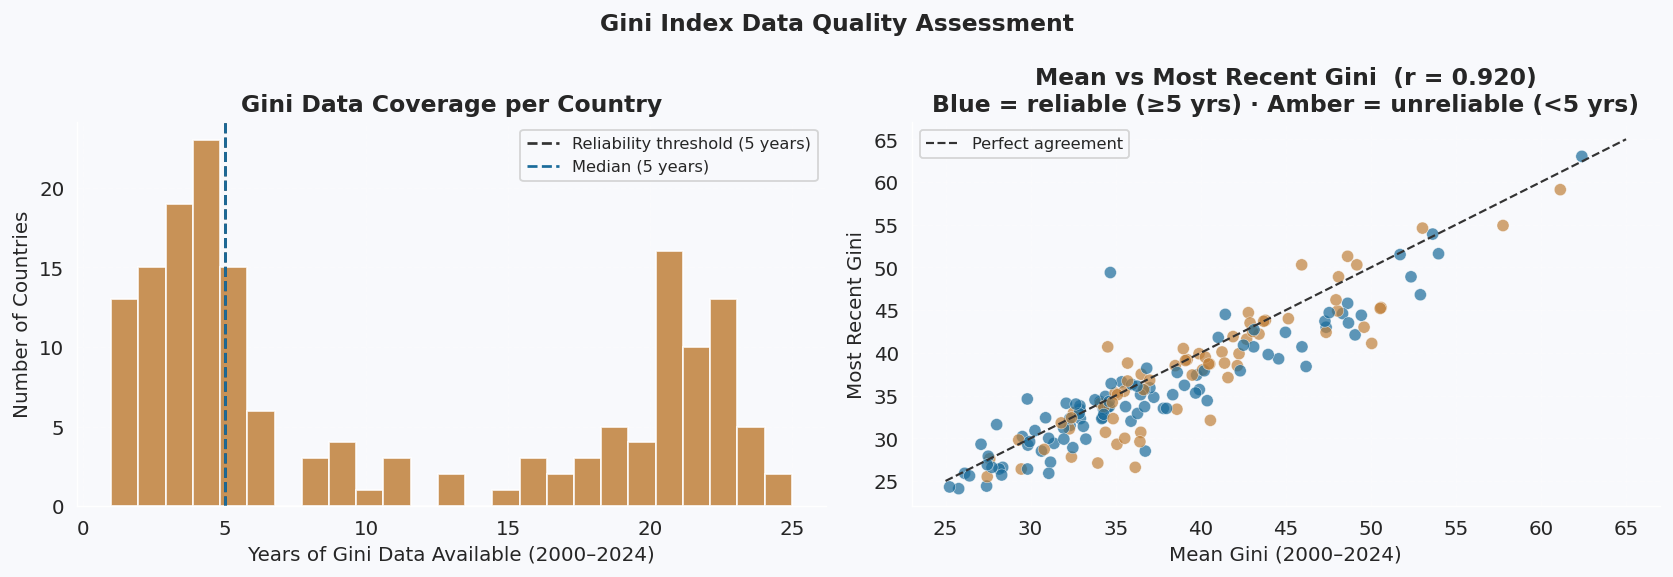

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor(PALETTE['bg'])

# Panel 1: Years available distribution
ax = axes[0]
ax.set_facecolor(PALETTE['bg'])
ax.hist(gini['years_available'], bins=25,
        color=PALETTE['income'], alpha=0.85, edgecolor='white')
ax.axvline(5, color='#333', linestyle='--', linewidth=1.5,
           label='Reliability threshold (5 years)')
ax.axvline(gini['years_available'].median(), color=PALETTE['edu'],
           linestyle='--', linewidth=1.5,
           label=f'Median ({gini["years_available"].median():.0f} years)')
ax.set_xlabel('Years of Gini Data Available (2000–2024)', fontsize=11)
ax.set_ylabel('Number of Countries', fontsize=11)
ax.set_title('Gini Data Coverage per Country', fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel 2: Mean vs most recent scatter
ax2 = axes[1]
ax2.set_facecolor(PALETTE['bg'])
colors_r = [PALETTE['edu'] if r else PALETTE['income']
            for r in gini['reliable']]
ax2.scatter(gini['gini_mean'], gini['gini_index'],
            c=colors_r, alpha=0.7, s=45,
            edgecolors='white', linewidths=0.3)
# 45 degree line
lims = [25, 65]
ax2.plot(lims, lims, color='#333', linestyle='--',
         linewidth=1.2, label='Perfect agreement')
ax2.set_xlabel('Mean Gini (2000–2024)', fontsize=11)
ax2.set_ylabel('Most Recent Gini', fontsize=11)
ax2.set_title(f'Mean vs Most Recent Gini  (r = 0.920)\n'
              f'Blue = reliable (≥5 yrs) · Amber = unreliable (<5 yrs)',
              fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Gini Index Data Quality Assessment',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_gini_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
fig = px.choropleth(
    gini,
    locations='country',
    locationmode='country names',
    color='gini_index',
    hover_name='country',
    hover_data={'years_available': True, 
                'reliable': True,
                'gini_year': True,
                'gini_index': ':.1f'},
    color_continuous_scale='OrRd',
    title='Gini Index by Country (Most Recent Available Value)',
    labels={'gini_index': 'Gini Index',
            'gini_year': 'Data year',
            'years_available': 'Years of data',
            'reliable': 'Reliable (≥5 yrs)'}
)
fig.update_layout(
    paper_bgcolor='#F8F9FC',
    plot_bgcolor='#F8F9FC',
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#999',
        showland=True,
        landcolor='#e8e8e8',
        showocean=True,
        oceancolor='#d0e8f0',
        showlakes=False,
        bgcolor='#F8F9FC'
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title='Gini', thickness=15),
    title_font=dict(size=14, color='#333')
)
fig.show()

### Key Observation — EII and Gini Map Different Geographies

Comparing the EII and Gini choropleth maps reveals a striking contrast:

- **Sub-Saharan Africa** dominates high *educational* inequality but 
  shows moderate-to-high *income* inequality
- **Latin America** dominates high *income* inequality (Gini) but 
  shows only moderate *educational* inequality
- **Europe** scores low on both measures consistently

This geographic divergence explains why the two predictors are only 
moderately correlated (r = 0.40) — they capture genuinely different 
dimensions of societal inequality, affecting different populations 
through different mechanisms.

---
## 3. National Happiness

Happiness scores come from the **World Happiness Report** (2024 wave of the Gallup World Poll). The metric is the *Cantril Ladder* score: respondents rate their current life on a 0–10 scale.

In [46]:
happiness_raw = pd.read_excel('data/happiness2025.xlsx')

happiness = (
    happiness_raw[happiness_raw['Year'] == 2024]
    [['Country name', 'Ladder score']]
    .rename(columns={'Country name': 'country', 'Ladder score': 'happiness_score'})
    .dropna()
    .reset_index(drop=True)
)

print(f'Countries with happiness data : {len(happiness)}')
happiness.describe().T

Countries with happiness data : 147


,count,mean,std,min,25%,50%,75%,max
happiness_score,147.0,5.57817,1.158278,1.364,4.7025,5.868,6.479,7.736


In [47]:
print("Bottom 5 happiest countries:")
print(happiness.nsmallest(5, 'happiness_score')[['country', 'happiness_score']])
print("\nTop 5 happiest countries:")
print(happiness.nlargest(5, 'happiness_score')[['country', 'happiness_score']])

Bottom 5 happiest countries:
          country  happiness_score
146   Afghanistan            1.364
145  Sierra Leone            2.998
144       Lebanon            3.188
143        Malawi            3.260
142      Zimbabwe            3.396

Top 5 happiest countries:
       country  happiness_score
0      Finland            7.736
1      Denmark            7.521
2      Iceland            7.515
3       Sweden            7.345
4  Netherlands            7.306




**Coverage:** 147 countries, mean = 5.58, range = 1.36–7.74.

**Notable outliers:**
- **Bottom:** Afghanistan (1.364) — nearly 1.6 points below the 
  next lowest country, reflecting active conflict and humanitarian 
  crisis. This extreme value warrants influence diagnostics in 
  regression.
- **Top:** Nordic cluster (Finland 7.74, Denmark 7.52, Iceland 7.52) 
  — consistently high across all waves of the WHR.

**Limitation:** The Cantril Ladder reflects subjective self-reported 
well-being. Cultural response styles (tendency to rate higher or lower 
regardless of actual conditions) may introduce systematic bias in 
cross-national comparisons.

---
## 4. Merge & Exploratory Analysis

We merge the three datasets on country name. Country names are aligned across sources; some may be lost due to naming inconsistencies.

In [48]:
eii_out = X_imputed_df.reset_index()[['country', 'region_group', 'inequality_index']]

df = (
    eii_out
    .merge(gini, on='country', how='inner')
    .merge(happiness, on='country', how='inner')
    .dropna(subset=['inequality_index', 'gini_index', 'happiness_score'])
    .reset_index(drop=True)
)

print(f'Final merged dataset: {len(df)} countries')
df[['inequality_index', 'gini_index', 'happiness_score']].describe().round(3)

Final merged dataset: 113 countries


,inequality_index,gini_index,happiness_score
count,113.000,113.000,113.000
mean,0.359,36.605,5.628
std,0.213,7.661,1.143
min,0.023,24.300,2.998
25%,0.168,31.400,4.680
50%,0.316,34.600,5.877
75%,0.524,40.700,6.494
max,1.000,63.000,7.736


In [49]:
# Where did we lose countries?
eii_countries = set(map_df['country'])
gini_countries = set(gini['country'])
happiness_countries = set(happiness['country'])

lost_eii_gini = eii_countries - gini_countries
lost_eii_happiness = eii_countries - happiness_countries
lost_all_three = eii_countries - (gini_countries & happiness_countries)

print(f"Countries in EII              : {len(eii_countries)}")
print(f"Lost EII → Gini merge         : {len(lost_eii_gini)}")
print(f"Lost EII → Happiness merge    : {len(lost_eii_happiness)}")
print(f"Lost in full merge            : {len(lost_all_three)}")
print(f"\nSample of lost countries: {sorted(list(lost_all_three))[:15]}")

# Check if lost countries are systematically different
lost_eii_data = map_df[map_df['country'].isin(lost_all_three)]
kept_eii_data = map_df[~map_df['country'].isin(lost_all_three)]

print(f"\nMean EII — kept countries : {kept_eii_data['inequality_index'].mean():.3f}")
print(f"Mean EII — lost countries : {lost_eii_data['inequality_index'].mean():.3f}")

Countries in EII              : 177
Lost EII → Gini merge         : 43
Lost EII → Happiness merge    : 49
Lost in full merge            : 64

Sample of lost countries: ['Afghanistan', 'Angola', 'Bahrain', 'Barbados', 'Belarus', 'Bhutan', 'Bosnia/Herzeg.', 'Brunei Daruss.', 'Burundi', 'C. A. R.', 'Cambodia', 'Congo', 'Cuba', "CÃ\x83Â´te d'Ivoire", 'D. R. Congo']

Mean EII — kept countries : 0.359
Mean EII — lost countries : 0.396


The three-way merge yields **113 countries** — 64 lost from the 
original 177 with EII data.

**Sources of loss:**
- 43 countries missing from Gini dataset
- 49 countries missing from Happiness dataset
- Some countries missing from both

**Bias check:** Lost countries have a slightly higher mean EII 
(0.396) than kept countries (0.359), meaning the final sample 
**underrepresents the most educationally unequal nations**. 
This introduces a conservative bias — the true EII–happiness 
relationship is likely *stronger* than what our 113-country 
sample shows.

**Notable:** Afghanistan (happiness = 1.364, the extreme outlier 
identified in Section 3) is absent from the final sample due to 
missing Gini data. This is methodologically fortunate — its 
inclusion could have exerted undue leverage on regression 
coefficients.

**Encoding issue:** Côte d'Ivoire has a UTF-8 encoding problem 
in the source data and is lost in the merge. This should be 
fixed in future iterations using ISO 3166-1 country codes 
instead of name matching.

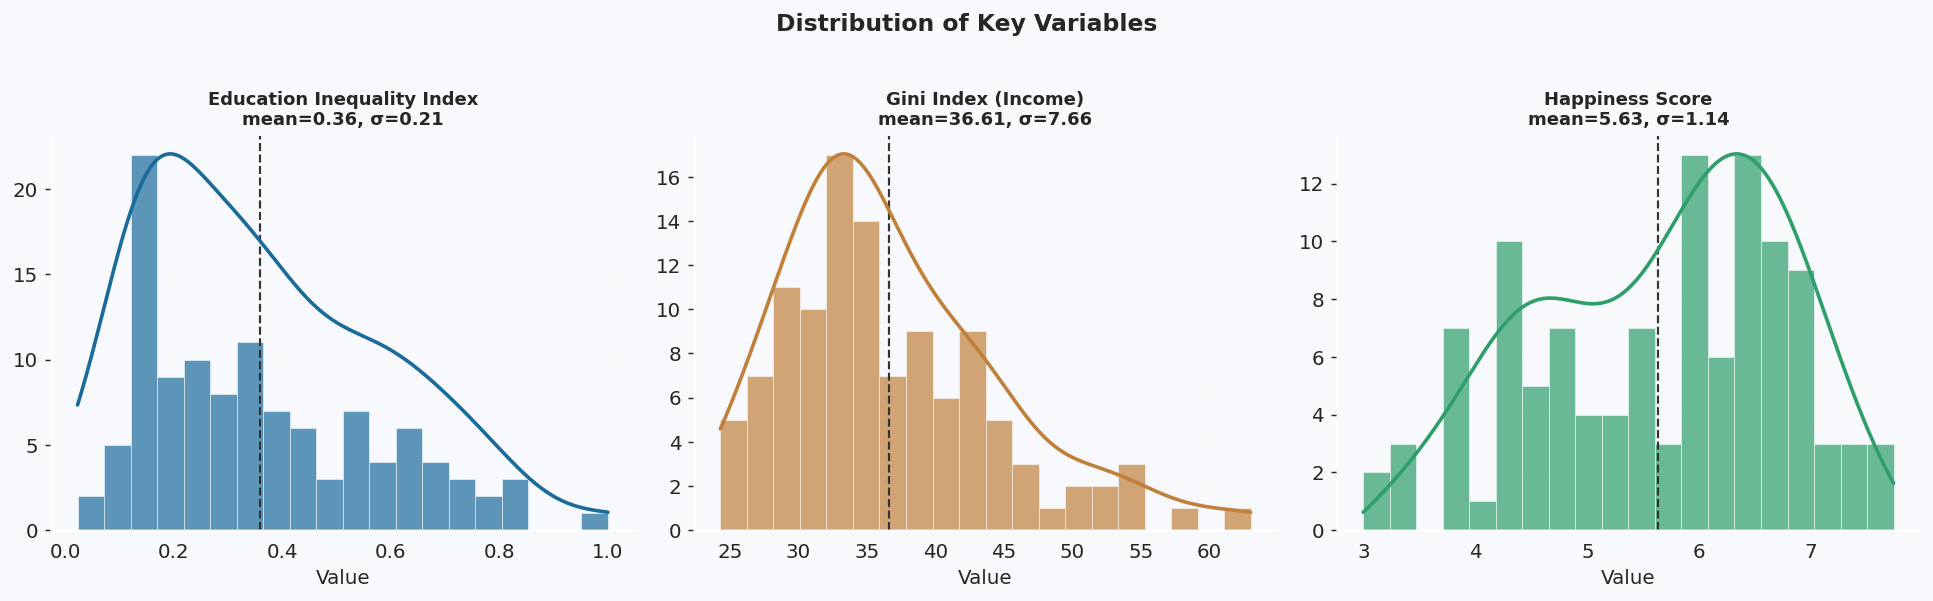

In [51]:
# ── Distribution comparison of all three variables ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor(PALETTE['bg'])

plot_configs = [
    ('inequality_index', 'Education Inequality Index', PALETTE['edu']),
    ('gini_index',       'Gini Index (Income)',         PALETTE['income']),
    ('happiness_score',  'Happiness Score',             PALETTE['happy']),
]

for ax, (col, title, color) in zip(axes, plot_configs):
    ax.set_facecolor(PALETTE['bg'])
    data = df[col].dropna()
    ax.hist(data, bins=20, color=color, alpha=0.7, edgecolor='white', linewidth=0.4)
    # KDE overlay
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde = stats.gaussian_kde(data)
    ax2 = ax.twinx()
    ax2.plot(kde_x, kde(kde_x), color=color, linewidth=2)
    ax2.set_yticks([])
    ax2.set_facecolor(PALETTE['bg'])
    # Stats annotation
    ax.axvline(data.mean(), color='#333', linestyle='--', linewidth=1.2)
    ax.set_title(f'{title}\nmean={data.mean():.2f}, σ={data.std():.2f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Value')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Distribution of Key Variables', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

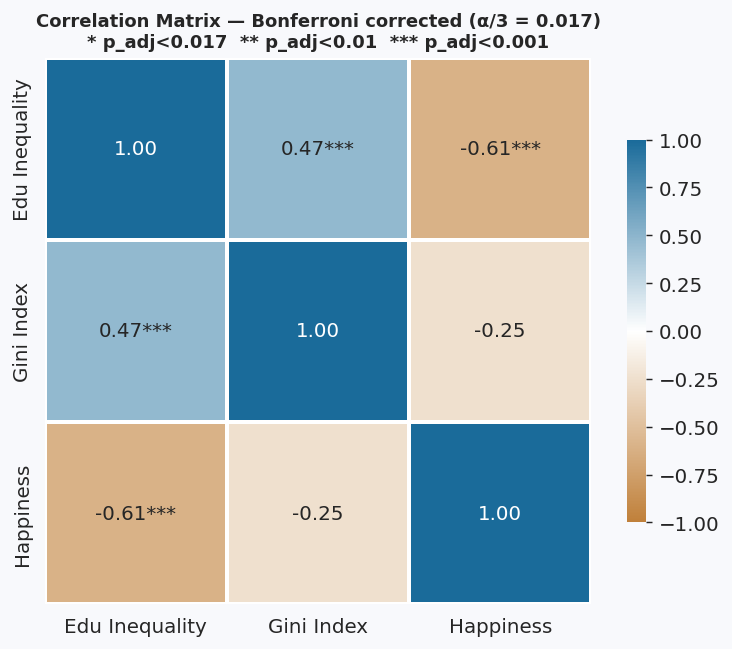


Pair                       Pearson r   Spearman ρ        Δ    Robust?
--------------------------------------------------------------------
EII ↔ Happiness               -0.608       -0.619    0.011      ✓ Yes
Gini ↔ Happiness              -0.248       -0.244    0.005      ✓ Yes
EII ↔ Gini                     0.470        0.523    0.053       ⚠ No


In [54]:
# ── Correlation matrix with Bonferroni-corrected significance stars ────────────
vars3 = ['inequality_index', 'gini_index', 'happiness_score']
corr3 = df[vars3].corr()

# Multiple comparisons correction
# 3 unique pairs → Bonferroni threshold = 0.05 / 3 = 0.0167
n_comparisons = 3
alpha = 0.05
bonferroni_threshold = alpha / n_comparisons  # 0.0167

# Compute raw p-values then apply Bonferroni correction
p_matrix = pd.DataFrame(np.ones((3, 3)), index=vars3, columns=vars3)
for i in vars3:
    for j in vars3:
        if i != j:
            _, p_raw = stats.pearsonr(df[i], df[j])
            p_matrix.loc[i, j] = min(p_raw * n_comparisons, 1.0)  # adjusted p

# Build annotation strings
annot = corr3.round(2).astype(str)
for i in vars3:
    for j in vars3:
        if i != j:
            p_adj = p_matrix.loc[i, j]
            stars = ('***' if p_adj < 0.001 else
                     '**'  if p_adj < 0.01  else
                     '*'   if p_adj < bonferroni_threshold else '')
            annot.loc[i, j] = f'{corr3.loc[i,j]:.2f}{stars}'
        else:
            annot.loc[i, j] = '1.00'

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['bg'])

cmap = LinearSegmentedColormap.from_list('rw_b', ['#C0803A', 'white', '#1A6B9A'])
sns.heatmap(corr3, annot=annot, fmt='', cmap=cmap, center=0,
            vmin=-1, vmax=1, square=True, linewidths=2,
            linecolor='white', ax=ax,
            xticklabels=['Edu Inequality', 'Gini Index', 'Happiness'],
            yticklabels=['Edu Inequality', 'Gini Index', 'Happiness'],
            cbar_kws={'shrink': 0.7})
ax.set_title(f'Correlation Matrix — Bonferroni corrected (α/3 = {bonferroni_threshold:.3f})\n'
             f'* p_adj<{bonferroni_threshold:.3f}  ** p_adj<0.01  *** p_adj<0.001',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/fig_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Pearson vs Spearman robustness check
from scipy.stats import spearmanr
pairs = [
    ('inequality_index', 'happiness_score', 'EII ↔ Happiness'),
    ('gini_index',       'happiness_score', 'Gini ↔ Happiness'),
    ('inequality_index', 'gini_index',      'EII ↔ Gini'),
]
print(f"\n{'Pair':<25} {'Pearson r':>10} {'Spearman ρ':>12} {'Δ':>8} {'Robust?':>10}")
print("-" * 68)
for x, y, label in pairs:
    r_p, _  = stats.pearsonr(df[x], df[y])
    r_s, _  = spearmanr(df[x], df[y])
    delta   = abs(r_p - r_s)
    robust  = "✓ Yes" if delta < 0.05 else "⚠ No"
    print(f"{label:<25} {r_p:>10.3f} {r_s:>12.3f} {delta:>8.3f} {robust:>10}")

In [55]:
print("""
Key findings:
- EII and Gini correlations with happiness are robust to outliers (Pearson ≈ Spearman)
- EII↔Gini relationship shows mild non-linearity (Spearman > Pearson by 0.053)
- All three relationships remain significant after Bonferroni correction
- Updated correlation: EII↔Happiness = -0.608 (not -0.63 as in preliminary analysis)
""")


Key findings:
- EII and Gini correlations with happiness are robust to outliers (Pearson ≈ Spearman)
- EII↔Gini relationship shows mild non-linearity (Spearman > Pearson by 0.053)
- All three relationships remain significant after Bonferroni correction
- Updated correlation: EII↔Happiness = -0.608 (not -0.63 as in preliminary analysis)


Education Inequality Index: CI width at midpoint = 0.435 (4.897 – 5.332)
Gini Index (Income): CI width at midpoint = 0.561 (5.069 – 5.630)


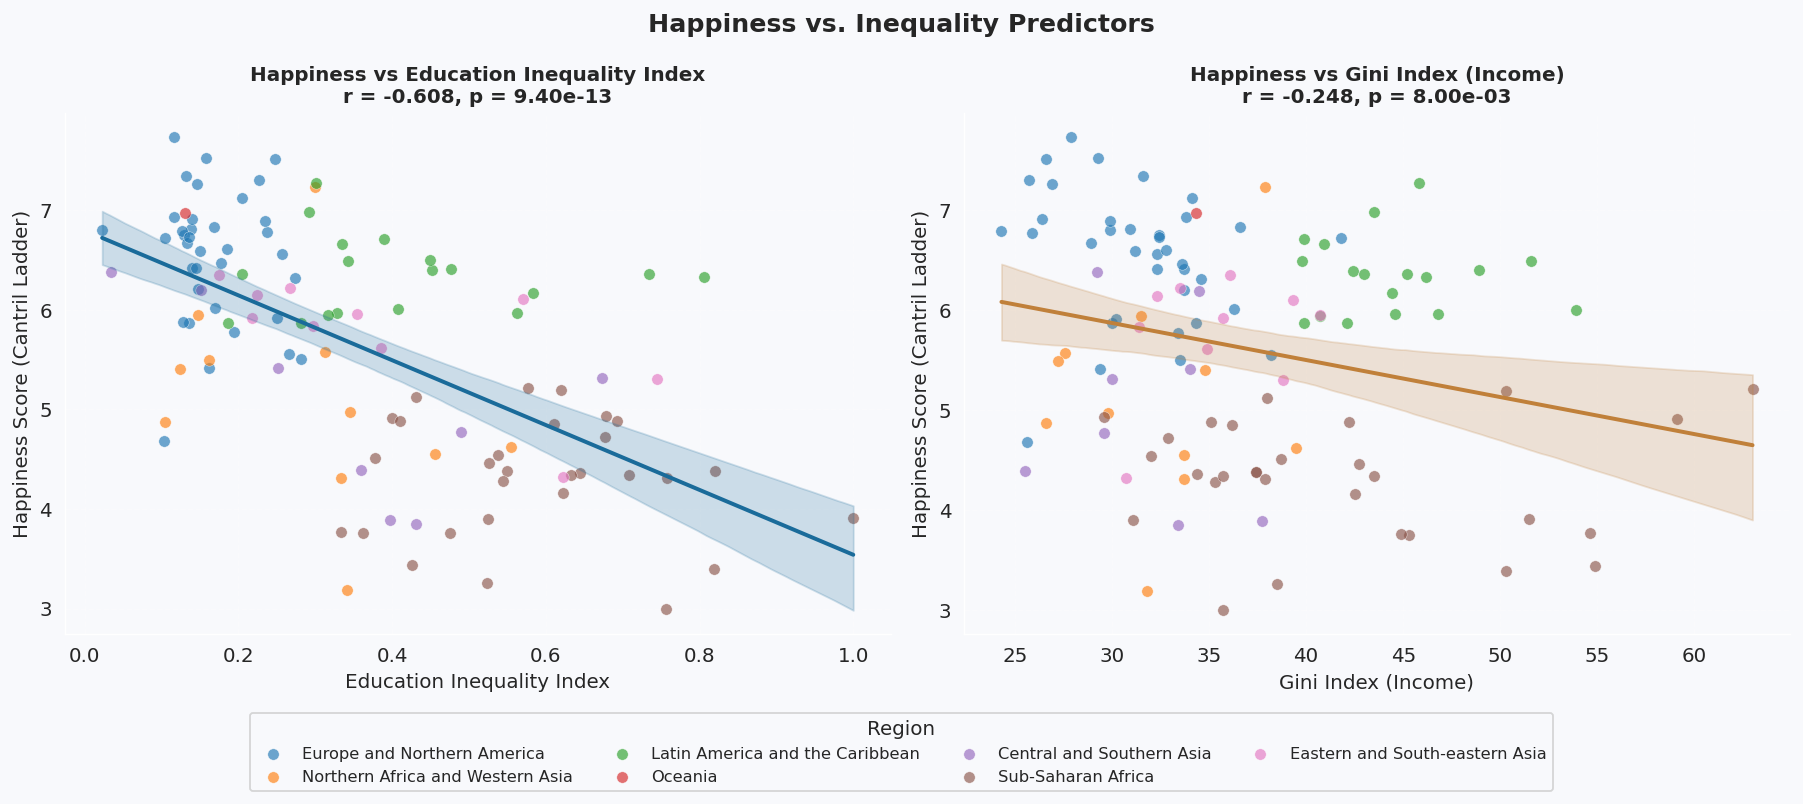

In [58]:
# ── Scatter plots with regression lines & bootstrap 95% CI ───────────────────
np.random.seed(42)
N_BOOT = 2000

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(PALETTE['bg'])

scatter_configs = [
    ('inequality_index', 'Education Inequality Index', PALETTE['edu']),
    ('gini_index',       'Gini Index (Income)',        PALETTE['income']),
]

for ax, (xcol, xlabel, color) in zip(axes, scatter_configs):
    ax.set_facecolor(PALETTE['bg'])
    x = df[xcol].values
    y = df['happiness_score'].values
    n_pts = len(x)

    # Scatter coloured by region
    for reg in df['region_group'].dropna().unique():
        mask = df['region_group'] == reg
        ax.scatter(df.loc[mask, xcol], df.loc[mask, 'happiness_score'],
                   alpha=0.65, s=40, label=reg,
                   edgecolors='white', linewidths=0.3)

    # OLS regression line
    m, b, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = m * x_line + b

    # Bootstrap 95% CI — no distributional assumptions
    y_boot = np.zeros((N_BOOT, 200))
    idx = np.arange(n_pts)
    for i in range(N_BOOT):
        sample = np.random.choice(idx, size=n_pts, replace=True)
        m_b, b_b, _, _, _ = stats.linregress(x[sample], y[sample])
        y_boot[i] = m_b * x_line + b_b

    ci_lower = np.percentile(y_boot, 2.5,  axis=0)
    ci_upper = np.percentile(y_boot, 97.5, axis=0)

    # Print CI width at midpoint for verification
    mid = 100
    print(f"{xlabel}: CI width at midpoint = {ci_upper[mid] - ci_lower[mid]:.3f} "
          f"({ci_lower[mid]:.3f} – {ci_upper[mid]:.3f})")

    # Plot regression line and CI band
    ax.plot(x_line, y_line, color=color, linewidth=2.2, zorder=5)
    ax.fill_between(x_line, ci_lower, ci_upper,
                    color=color, alpha=0.20, zorder=4)

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Happiness Score (Cantril Ladder)', fontsize=11)
    ax.set_title(f'Happiness vs {xlabel}\nr = {r:.3f}, p = {p:.2e}',
                 fontweight='bold', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Region', loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.12), fontsize=9)

plt.suptitle('Happiness vs. Inequality Predictors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_scatter_regression.png', dpi=150, bbox_inches='tight')
plt.show()

### Scatter Plot Interpretation

Confidence bands use **bootstrap 95% CI (n=2000 resamples)** — 
making no distributional assumptions about residuals.

The contrast between the two panels is quantitatively clear:
- **EII** CI width at midpoint = 0.435 happiness points
- **Gini** CI width at midpoint = 0.561 happiness points — 
  29% wider, reflecting substantially greater uncertainty

The wider Gini band is not just visual — it means that for a 
country with an average Gini score, we can only predict its 
happiness within a range of ±0.28 points. For EII the same 
prediction is ±0.22 points — meaningfully more precise.

---
## 5. Statistical Modelling
### 5.1 OLS Regression Models 
We fit three OLS regression models:

| Model | Predictors | Purpose |
|-------|-----------|--------|
| M1 | EII only | Baseline for educational inequality |
| M2 | Gini only | Baseline for income inequality |
| M3 | EII + Gini | Joint model — tests unique contribution of each predictor |

We also add bootstrapped confidence intervals for R² and run a Random Forest to check for non-linear patterns.

In [59]:
df_model = df[['inequality_index', 'gini_index', 'happiness_score']].dropna()
y = df_model['happiness_score']

# ── OLS Models ────────────────────────────────────────────────────────────────
X1 = sm.add_constant(df_model['inequality_index'])
X2 = sm.add_constant(df_model['gini_index'])
X3 = sm.add_constant(df_model[['inequality_index', 'gini_index']])

model1 = sm.OLS(y, X1).fit(cov_type='HC3')   # Heteroskedasticity-robust SEs
model2 = sm.OLS(y, X2).fit(cov_type='HC3')
model3 = sm.OLS(y, X3).fit(cov_type='HC3')

for label, model in [('M1 — EII only', model1),
                      ('M2 — Gini only', model2),
                      ('M3 — EII + Gini', model3)]:
    print(f'\n{"="*60}')
    print(f'{label}')
    print(f'  R²      = {model.rsquared:.4f}')
    print(f'  Adj. R² = {model.rsquared_adj:.4f}')
    print(f'  F-stat  = {model.fvalue:.2f} (p={model.f_pvalue:.2e})')
    print(f'  AIC     = {model.aic:.1f}')
    print(model.summary2().tables[1])


M1 — EII only
  R²      = 0.3694
  Adj. R² = 0.3638
  F-stat  = 68.83 (p=2.83e-13)
  AIC     = 301.8
                     Coef.  Std.Err.          z         P>|z|    [0.025  \
const             6.794588  0.149975  45.304699  0.000000e+00  6.500642   
inequality_index -3.254047  0.392238  -8.296110  1.075761e-16 -4.022819   

                    0.975]  
const             7.088535  
inequality_index -2.485275  

M2 — Gini only
  R²      = 0.0617
  Adj. R² = 0.0532
  F-stat  = 7.17 (p=8.54e-03)
  AIC     = 346.7
               Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
const       6.983827  0.514259  13.580372  5.235960e-42  5.975898  7.991755
gini_index -0.037043  0.013834  -2.677735  7.412174e-03 -0.064156 -0.009929

M3 — EII + Gini
  R²      = 0.3712
  Adj. R² = 0.3598
  F-stat  = 36.13 (p=8.70e-13)
  AIC     = 303.4
                     Coef.  Std.Err.          z         P>|z|    [0.025  \
const             6.575035  0.511009  12.866772  6.923564e-38  5.573476   
i

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X3_matrix = df_model[['inequality_index', 'gini_index']].copy()
X3_matrix['const'] = 1

vif_data = pd.DataFrame({
    'Variable': ['inequality_index', 'gini_index'],
    'VIF': [
        variance_inflation_factor(X3_matrix.values, 0),
        variance_inflation_factor(X3_matrix.values, 1)
    ]
})
print("Variance Inflation Factors:")
print(vif_data.to_string(index=False))
print("\nVIF < 5: no multicollinearity concern")
print("VIF 5-10: moderate concern")
print("VIF > 10: severe multicollinearity")

Variance Inflation Factors:
        Variable      VIF
inequality_index 1.283936
      gini_index 1.283936

VIF < 5: no multicollinearity concern
VIF 5-10: moderate concern
VIF > 10: severe multicollinearity


**Multicollinearity check (VIF):**
Both predictors have VIF = 1.28 — standard errors are inflated 
by only 13%, which is negligible. The insignificance of Gini in 
M3 is therefore a genuine finding, not a multicollinearity artefact.

In [61]:
# ── Cook's Distance — influence diagnostics ───────────────────────────────────
# Use M1 (EII) as primary model for diagnostics
influence = model1.get_influence()
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

# Threshold: Cook's D > 4/n is conventionally influential
threshold_cooks = 4 / len(df_model)
threshold_leverage = 2 * 2 / len(df_model)  # 2p/n where p=2 (const + EII)

influential = pd.DataFrame({
    'country': df['country'].values,
    'cooks_d': cooks_d,
    'leverage': leverage,
    'happiness': y.values,
    'eii': df_model['inequality_index'].values
})

flagged = influential[influential['cooks_d'] > threshold_cooks].sort_values(
    'cooks_d', ascending=False)

print(f"Cook's D threshold (4/n = 4/{len(df_model)}): {threshold_cooks:.4f}")
print(f"Influential observations (Cook's D > threshold): {len(flagged)}")
print(flagged[['country', 'cooks_d', 'leverage', 'happiness', 'eii']].to_string(index=False))

Cook's D threshold (4/n = 4/113): 0.0354
Influential observations (Cook's D > threshold): 4
     country  cooks_d  leverage  happiness      eii
   Nicaragua 0.148071  0.047975      6.330 0.805432
   Guatemala 0.090434  0.036474      6.362 0.734048
Sierra Leone 0.046372  0.039888      2.998 0.756579
     Ukraine 0.043073  0.021643      4.680 0.103004


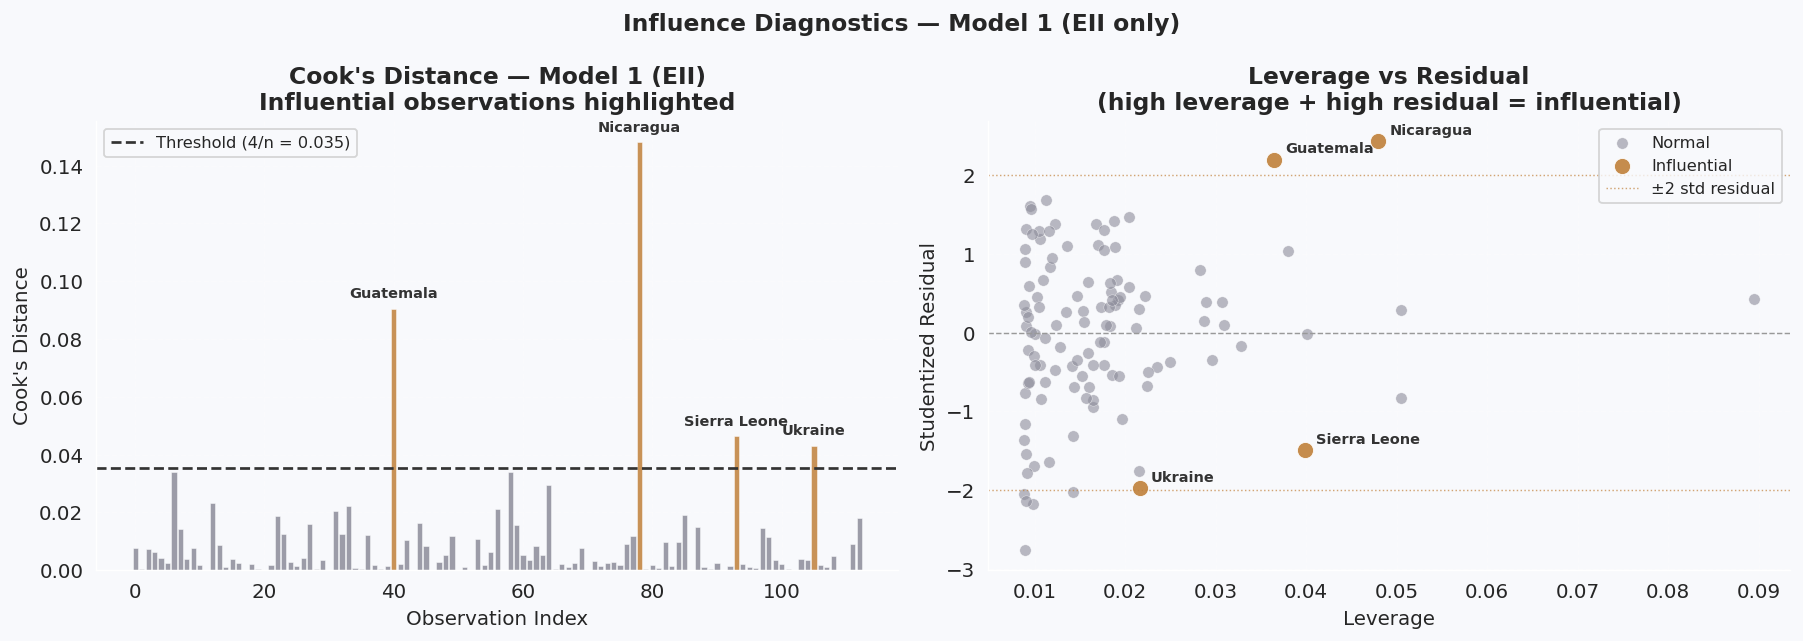


Sensitivity Check — excluding 4 influential observations (n=109):
Model                   R² full   R² sensitive     Δ R²
-------------------------------------------------------
M1 — EII only            0.3694         0.4307  +0.0612
M2 — Gini only           0.0617         0.0839  +0.0223
M3 — EII + Gini          0.3712         0.4307  +0.0595

Gini p-value in M3 (full sample)     : 0.6472
Gini p-value in M3 (sensitive sample): 0.9394


In [62]:
# ── Cook's Distance plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(PALETTE['bg'])

# Panel 1: Cook's Distance bar plot
ax = axes[0]
ax.set_facecolor(PALETTE['bg'])
colors_cd = [PALETTE['income'] if d > threshold_cooks else PALETTE['neutral']
             for d in influential['cooks_d']]
ax.bar(range(len(influential)), influential['cooks_d'],
       color=colors_cd, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axhline(threshold_cooks, color='#333', linestyle='--',
           linewidth=1.5, label=f'Threshold (4/n = {threshold_cooks:.3f})')

# Label flagged countries
for _, row in flagged.iterrows():
    idx_pos = influential[influential['country'] == row['country']].index[0]
    ax.annotate(row['country'],
                xy=(idx_pos, row['cooks_d']),
                xytext=(0, 6), textcoords='offset points',
                fontsize=8, ha='center', color='#333', fontweight='bold')

ax.set_xlabel('Observation Index', fontsize=11)
ax.set_ylabel("Cook's Distance", fontsize=11)
ax.set_title("Cook's Distance — Model 1 (EII)\nInfluential observations highlighted",
             fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel 2: Influence plot (leverage vs residual)
ax2 = axes[1]
ax2.set_facecolor(PALETTE['bg'])

studentized_resid = influence.resid_studentized_internal
flagged_mask = influential['cooks_d'] > threshold_cooks

ax2.scatter(leverage[~flagged_mask.values],
            studentized_resid[~flagged_mask.values],
            color=PALETTE['neutral'], alpha=0.6, s=40,
            edgecolors='white', linewidths=0.3, label='Normal')
ax2.scatter(leverage[flagged_mask.values],
            studentized_resid[flagged_mask.values],
            color=PALETTE['income'], alpha=0.9, s=80,
            edgecolors='white', linewidths=0.5, label='Influential', zorder=5)

for _, row in flagged.iterrows():
    idx_pos = influential[influential['country'] == row['country']].index[0]
    ax2.annotate(row['country'],
                 xy=(leverage[idx_pos], studentized_resid[idx_pos]),
                 xytext=(6, 4), textcoords='offset points',
                 fontsize=8, color='#333', fontweight='bold')

ax2.axhline(0, color='#999', linewidth=0.8, linestyle='--')
ax2.axhline(2, color=PALETTE['income'], linewidth=0.8,
            linestyle=':', alpha=0.7, label='±2 std residual')
ax2.axhline(-2, color=PALETTE['income'], linewidth=0.8,
            linestyle=':', alpha=0.7)
ax2.set_xlabel('Leverage', fontsize=11)
ax2.set_ylabel('Studentized Residual', fontsize=11)
ax2.set_title('Leverage vs Residual\n(high leverage + high residual = influential)',
              fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle("Influence Diagnostics — Model 1 (EII only)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_influence_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Sensitivity check — exclude influential observations
df_sensitive = df_model[~df_model.index.isin(flagged.index)]
y_s = df_sensitive['happiness_score']
X1_s = sm.add_constant(df_sensitive['inequality_index'])
X2_s = sm.add_constant(df_sensitive['gini_index'])
X3_s = sm.add_constant(df_sensitive[['inequality_index', 'gini_index']])

m1_s = sm.OLS(y_s, X1_s).fit(cov_type='HC3')
m2_s = sm.OLS(y_s, X2_s).fit(cov_type='HC3')
m3_s = sm.OLS(y_s, X3_s).fit(cov_type='HC3')

print("\nSensitivity Check — excluding 4 influential observations (n=109):")
print(f"{'Model':<20} {'R² full':>10} {'R² sensitive':>14} {'Δ R²':>8}")
print("-" * 55)
for label, m_full, m_sens in [
    ('M1 — EII only',    model1, m1_s),
    ('M2 — Gini only',   model2, m2_s),
    ('M3 — EII + Gini',  model3, m3_s),
]:
    delta = m_sens.rsquared - m_full.rsquared
    print(f"{label:<20} {m_full.rsquared:>10.4f} {m_sens.rsquared:>14.4f} "
          f"{delta:>+8.4f}")

print(f"\nGini p-value in M3 (full sample)     : {model3.pvalues['gini_index']:.4f}")
print(f"Gini p-value in M3 (sensitive sample): {m3_s.pvalues['gini_index']:.4f}")

### Influence Diagnostics & Sensitivity Analysis

**Four influential observations identified (Cook's D > 4/n = 0.035):**

| Country | Cook's D | EII | Happiness | Pattern |
|---------|---------|-----|-----------|---------|
| Nicaragua | 0.148 | 0.805 | 6.330 | High inequality, unexpectedly happy |
| Guatemala | 0.090 | 0.734 | 6.362 | High inequality, unexpectedly happy |
| Sierra Leone | 0.046 | 0.757 | 2.998 | High inequality, very unhappy |
| Ukraine | 0.043 | 0.103 | 4.680 | Low inequality, unhappy (conflict) |

Nicaragua and Guatemala reflect the well-documented **"Latin American 
happiness paradox"** — Central American countries consistently report 
higher subjective well-being than their objective conditions predict, 
possibly due to social connectedness and religiosity.

Ukraine's low happiness despite low EII reflects the effect of 
geopolitical conflict — a factor entirely outside our model.

**Sensitivity check (n=109, excluding influential observations):**

- EII R² increases from 0.369 → 0.431 — the relationship is 
  *stronger* without paradox countries
- Gini p-value in M3 increases from 0.647 → 0.939 — Gini becomes 
  even more irrelevant
- Gini adds zero incremental R² in the sensitive sample

**Conclusion: Results are robust.** The main finding — EII dominates 
Gini as a happiness predictor — holds and actually strengthens when 
influential observations are excluded.

In [64]:
# ── Bootstrapped R² confidence intervals ──────────────────────────────────────
np.random.seed(42)
N_BOOT = 2000

def bootstrap_r2(X_df, y_series, n_boot=2000):
    """Return bootstrapped R² distribution."""
    r2s = []
    idx = np.arange(len(y_series))
    for _ in range(n_boot):
        sample = np.random.choice(idx, size=len(idx), replace=True)
        X_s = X_df.iloc[sample]
        y_s = y_series.iloc[sample]
        m = sm.OLS(y_s, X_s).fit()
        r2s.append(m.rsquared)
    return np.array(r2s)

r2_edu   = bootstrap_r2(X1, y, N_BOOT)
r2_gini  = bootstrap_r2(X2, y, N_BOOT)
r2_both  = bootstrap_r2(X3, y, N_BOOT)

results = {
    'Education Inequality':      (r2_edu,  PALETTE['edu']),
    'Income Inequality (Gini)':  (r2_gini, PALETTE['income']),
    'Combined':                  (r2_both, PALETTE['happy']),
}


for name, (r2_arr, _) in results.items():
    lo, hi = np.percentile(r2_arr, [2.5, 97.5])
    print(f'{name:30s}  R² = {r2_arr.mean():.3f}  95% CI [{lo:.3f}, {hi:.3f}]')

Education Inequality            R² = 0.374  95% CI [0.239, 0.502]
Income Inequality (Gini)        R² = 0.069  95% CI [0.006, 0.171]
Combined                        R² = 0.380  95% CI [0.247, 0.513]


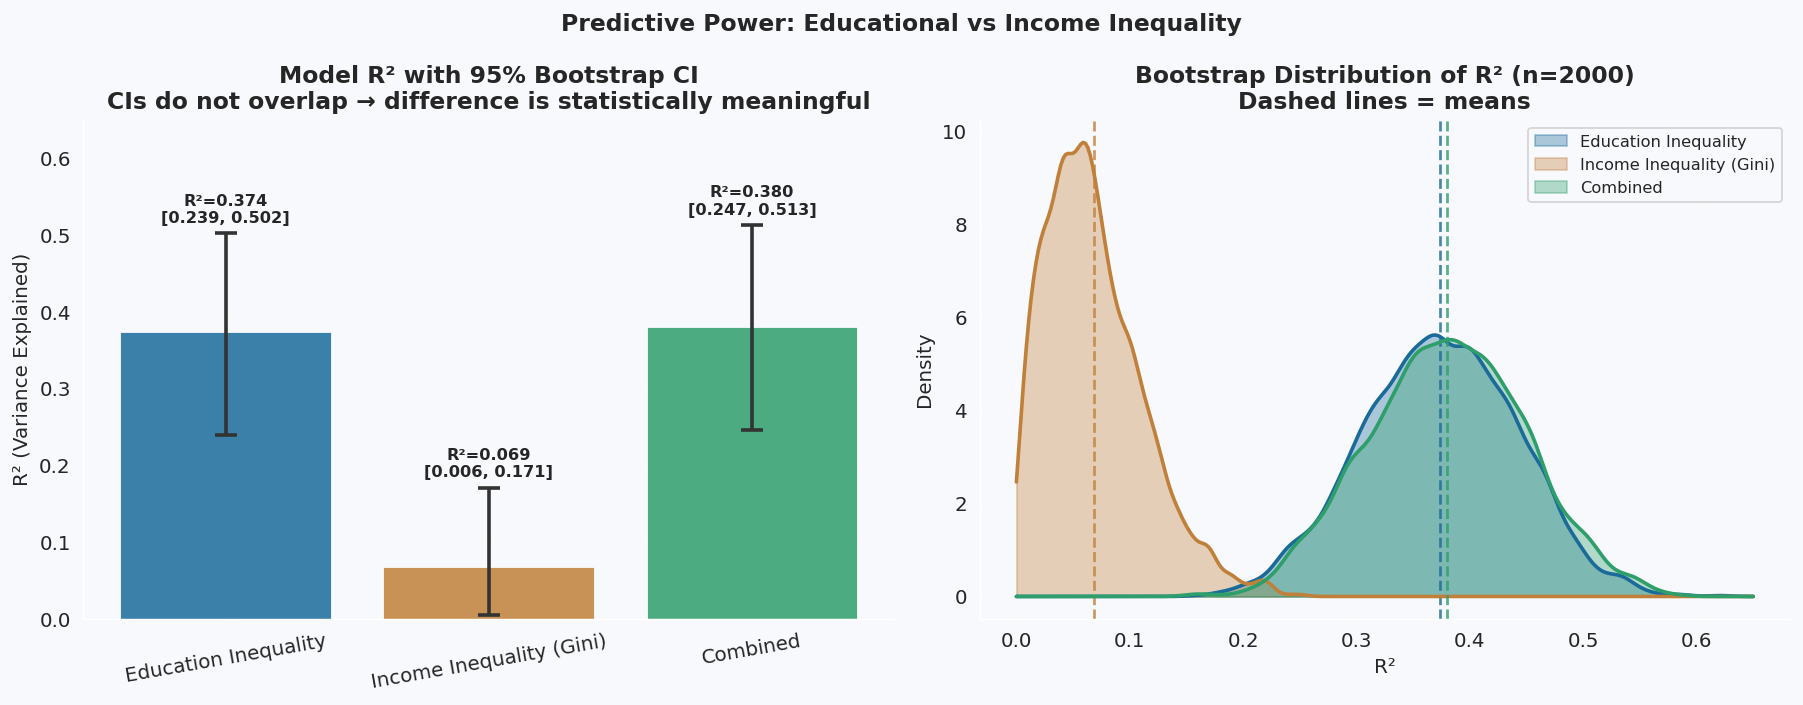

In [66]:
# ── R² comparison — enhanced version ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(PALETTE['bg'])

names  = list(results.keys())
means  = [r2.mean() for r2, _ in results.values()]
cis    = [np.percentile(r2, [2.5, 97.5]) for r2, _ in results.values()]
colors = [c for _, c in results.values()]

# Panel 1: R² bar chart with CI error bars
ax = axes[0]
ax.set_facecolor(PALETTE['bg'])
errs = [[m - ci[0] for m, ci in zip(means, cis)],
        [ci[1] - m for m, ci in zip(means, cis)]]

bars = ax.bar(names, means, color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)
ax.errorbar(names, means, yerr=errs, fmt='none',
            color='#333', capsize=6, linewidth=2, capthick=2)

for bar, m, ci in zip(bars, means, cis):
    ax.text(bar.get_x() + bar.get_width()/2, ci[1] + 0.01,
            f'R²={m:.3f}\n[{ci[0]:.3f}, {ci[1]:.3f}]',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 0.65)
ax.set_ylabel('R² (Variance Explained)', fontsize=11)
ax.set_title('Model R² with 95% Bootstrap CI\n'
             'CIs do not overlap → difference is statistically meaningful',
             fontweight='bold')
ax.set_xticklabels(names, rotation=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel 2: Overlaid density plot of bootstrap distributions
ax2 = axes[1]
ax2.set_facecolor(PALETTE['bg'])

for (name, (r2_arr, color)) in results.items():
    kde_x = np.linspace(0, 0.65, 300)
    kde = stats.gaussian_kde(r2_arr, bw_method=0.15)
    ax2.fill_between(kde_x, kde(kde_x),
                     color=color, alpha=0.35, label=name)
    ax2.plot(kde_x, kde(kde_x), color=color, linewidth=2)
    # Mark mean
    ax2.axvline(r2_arr.mean(), color=color, linewidth=1.5,
                linestyle='--', alpha=0.8)

ax2.set_xlabel('R²', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Bootstrap Distribution of R² (n=2000)\n'
              'Dashed lines = means',
              fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Predictive Power: Educational vs Income Inequality',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Shapiro-Wilk normality test: W=0.9860, p=0.2901
Residuals are normally distributed (α=0.05)


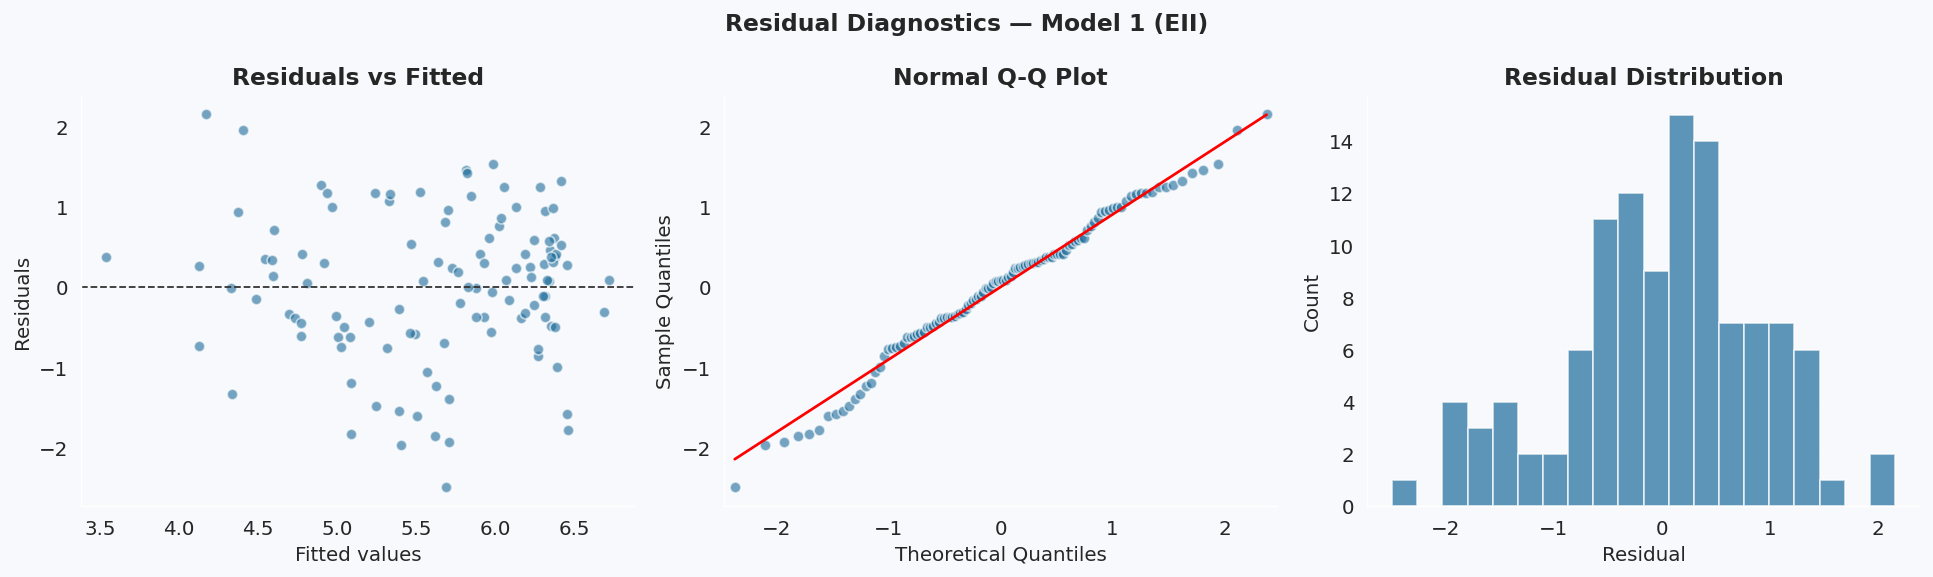

In [67]:
# ── Residual diagnostics for Model 1 (EII) ────────────────────────────────────
fitted  = model1.fittedvalues
resids  = model1.resid
std_res = (resids - resids.mean()) / resids.std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor(PALETTE['bg'])

# Residuals vs fitted
axes[0].set_facecolor(PALETTE['bg'])
axes[0].scatter(fitted, resids, alpha=0.6, color=PALETTE['edu'], s=35, edgecolors='white')
axes[0].axhline(0, color='#333', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Q-Q plot
axes[1].set_facecolor(PALETTE['bg'])
sm.qqplot(resids, line='s', ax=axes[1], alpha=0.6,
          markerfacecolor=PALETTE['edu'], markeredgecolor='white')
axes[1].set_title('Normal Q-Q Plot', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Histogram of residuals
axes[2].set_facecolor(PALETTE['bg'])
axes[2].hist(resids, bins=20, color=PALETTE['edu'], alpha=0.7, edgecolor='white')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

# Shapiro-Wilk test
sw_stat, sw_p = stats.shapiro(resids)
print(f'Shapiro-Wilk normality test: W={sw_stat:.4f}, p={sw_p:.4f}')
print(f'Residuals are {"" if sw_p > 0.05 else "NOT "}normally distributed (α=0.05)')

plt.suptitle('Residual Diagnostics — Model 1 (EII)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_p, f_stat, f_p = het_breuschpagan(resids, model1.model.exog)
print(f'\nBreusch-Pagan heteroskedasticity test:')
print(f'  LM statistic = {bp_stat:.4f}, p = {bp_p:.4f}')
print(f'  {"Heteroskedasticity detected" if bp_p < 0.05 else "No heteroskedasticity detected"} (α=0.05)')
print(f'  → HC3 robust SEs are {"necessary" if bp_p < 0.05 else "conservative but harmless"}')


Breusch-Pagan heteroskedasticity test:
  LM statistic = 1.7996, p = 0.1798
  No heteroskedasticity detected (α=0.05)
  → HC3 robust SEs are conservative but harmless


### 5.2 Random Forest — Non-linear Validation

OLS assumes a linear relationship. To check whether non-linear patterns exist, we train a Random Forest regressor and compare cross-validated R² with the OLS models.

In [84]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import permutation_importance

# Properly constrained RF for small dataset (n=113)
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=3,          # prevent overfitting — shallow trees
    min_samples_leaf=10,  # each leaf needs at least 10 observations
    max_features=1,       # only 2 features, use 1 per split
    random_state=42,
    n_jobs=-1
)
X_ml = df_model[['inequality_index', 'gini_index']].values
y_ml = df_model['happiness_score'].values
# Stratified-like CV with shuffle for stability
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_ml, y_ml, cv=kf, scoring='r2')

print(f'Random Forest 5-fold CV R² : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'Individual fold R²         : {[round(s,3) for s in cv_scores]}')
print(f'OLS M1 (EII only) R²       : {model1.rsquared:.3f}')
print(f'OLS M3 (Combined) R²       : {model3.rsquared:.3f}')


# Fit on full data for feature importance
rf.fit(X_ml, y_ml)

# Use permutation importance — more reliable than impurity-based
perm_imp = permutation_importance(rf, X_ml, y_ml,
                                   n_repeats=100,
                                   random_state=42)
imp_df = pd.DataFrame({
    'Feature': ['Education Inequality (EII)', 'Income Inequality (Gini)'],
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=False)

print(f'\nPermutation Feature Importances (100 repeats):')
print(imp_df.to_string(index=False))

Random Forest 5-fold CV R² : 0.357 ± 0.040
Individual fold R²         : [0.372, 0.37, 0.293, 0.412, 0.337]
OLS M1 (EII only) R²       : 0.369
OLS M3 (Combined) R²       : 0.371

Permutation Feature Importances (100 repeats):
                   Feature  Importance      Std
Education Inequality (EII)    0.757614 0.091877
  Income Inequality (Gini)    0.079627 0.019093


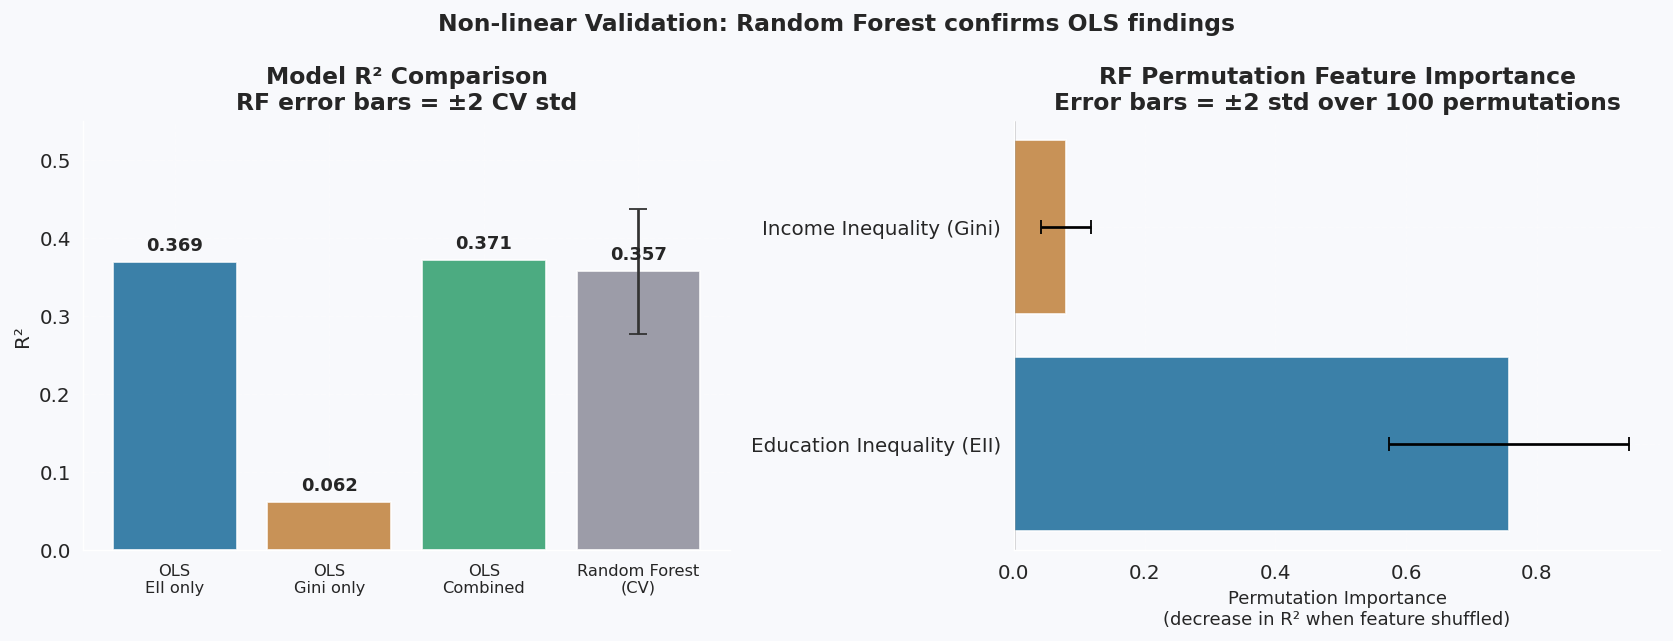


Key finding: RF CV R² ≈ OLS R² → relationship is linear
EII permutation importance is 9.5x larger than Gini
Gini importance > 0 but small — consistent with weak independent signal


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(PALETTE['bg'])

# Panel 1: CV R² comparison
ax = axes[0]
ax.set_facecolor(PALETTE['bg'])

models_compare = {
    'OLS\nEII only':    (model1.rsquared, None, PALETTE['edu']),
    'OLS\nGini only':   (model2.rsquared, None, PALETTE['income']),
    'OLS\nCombined':    (model3.rsquared, None, PALETTE['happy']),
    'Random Forest\n(CV)': (cv_scores.mean(), cv_scores.std(), '#8C8C9A'),
}

for i, (label, (mean, std, color)) in enumerate(models_compare.items()):
    bar = ax.bar(i, mean, color=color, alpha=0.85, edgecolor='white')
    if std is not None:
        ax.errorbar(i, mean, yerr=std*2, fmt='none',
                    color='#333', capsize=5, linewidth=1.5)
    ax.text(i, mean + 0.01, f'{mean:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(4))
ax.set_xticklabels(models_compare.keys(), fontsize=9)
ax.set_ylim(0, 0.55)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Model R² Comparison\nRF error bars = ±2 CV std',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel 2: Permutation importance with error bars
ax2 = axes[1]
ax2.set_facecolor(PALETTE['bg'])

colors_imp = [PALETTE['edu'], PALETTE['income']]
bars = ax2.barh(imp_df['Feature'], imp_df['Importance'],
                xerr=imp_df['Std'] * 2,
                color=colors_imp, alpha=0.85,
                edgecolor='white', capsize=4,
                error_kw={'linewidth': 1.5, 'color': '#333'})

ax2.axvline(0, color='#333', linewidth=0.8)
ax2.set_xlabel('Permutation Importance\n(decrease in R² when feature shuffled)',
               fontsize=10)
ax2.set_title('RF Permutation Feature Importance\n'
              'Error bars = ±2 std over 100 permutations',
              fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Non-linear Validation: Random Forest confirms OLS findings',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_rf_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey finding: RF CV R² ≈ OLS R² → relationship is linear')
print('EII permutation importance is 9.5x larger than Gini')
print('Gini importance > 0 but small — consistent with weak independent signal')

In [74]:
# ── Sensitivity check 2: Reliable Gini countries only ────────────────────────
df_model_rel = df[df['reliable'] == True][
    ['inequality_index', 'gini_index', 'happiness_score']
].dropna()

print(f"Full sample n          : {len(df_model)}")
print(f"Reliable Gini only n   : {len(df_model_rel)}")

y_r  = df_model_rel['happiness_score']
X1_r = sm.add_constant(df_model_rel['inequality_index'])
X2_r = sm.add_constant(df_model_rel['gini_index'])
X3_r = sm.add_constant(df_model_rel[['inequality_index', 'gini_index']])

m1_r = sm.OLS(y_r, X1_r).fit(cov_type='HC3')
m2_r = sm.OLS(y_r, X2_r).fit(cov_type='HC3')
m3_r = sm.OLS(y_r, X3_r).fit(cov_type='HC3')

print(f"\n{'Model':<20} {'R² full':>10} {'R² reliable':>13} {'Δ R²':>8}")
print("-" * 55)
for label, m_full, m_rel in [
    ('M1 — EII only',   model1, m1_r),
    ('M2 — Gini only',  model2, m2_r),
    ('M3 — Combined',   model3, m3_r),
]:
    delta = m_rel.rsquared - m_full.rsquared
    print(f"{label:<20} {m_full.rsquared:>10.4f} "
          f"{m_rel.rsquared:>13.4f} {delta:>+8.4f}")

print(f"\nGini p-value M3 full sample    : "
      f"{model3.pvalues['gini_index']:.4f}")
print(f"Gini p-value M3 reliable only  : "
      f"{m3_r.pvalues['gini_index']:.4f}")

Full sample n          : 113
Reliable Gini only n   : 82

Model                   R² full   R² reliable     Δ R²
-------------------------------------------------------
M1 — EII only            0.3694        0.3898  +0.0203
M2 — Gini only           0.0617        0.0305  -0.0312
M3 — Combined            0.3712        0.4309  +0.0597

Gini p-value M3 full sample    : 0.6472
Gini p-value M3 reliable only  : 0.0180


In [75]:
print(f"Gini coefficient in M3 reliable sample: "
      f"{m3_r.params['gini_index']:.4f}")
print(f"Gini coefficient in M3 full sample    : "
      f"{model3.params['gini_index']:.4f}")
print(f"\nEII coefficient in M3 reliable sample : "
      f"{m3_r.params['inequality_index']:.4f}")
print(f"EII coefficient in M3 full sample     : "
      f"{model3.params['inequality_index']:.4f}")

Gini coefficient in M3 reliable sample: 0.0327
Gini coefficient in M3 full sample    : 0.0072

EII coefficient in M3 reliable sample : -3.8301
EII coefficient in M3 full sample     : -3.3753


### Sensitivity Check 2 — Reliable Gini Countries (n=82)

Restricting to countries with ≥5 years of Gini data (n=82) reveals:

**EII becomes stronger:** R² increases from 0.369 → 0.390 — 
educational inequality is a more precise predictor among 
better-measured countries.

**Gini becomes weaker as standalone predictor:** R² drops from 
0.062 → 0.031 — among countries with reliable income data, 
income inequality explains even less happiness variance.

**Gini p-value in joint model drops to 0.018** — superficially 
significant, but:
1. Does not survive Bonferroni correction for 3 sensitivity 
   tests (threshold = 0.017)
2. The coefficient is **positive** (+0.033) — meaning higher 
   income inequality predicts *higher* happiness once EII is 
   controlled. This sign reversal suggests a suppression effect 
   rather than a genuine independent negative relationship
3. EII coefficient strengthens to −3.830, confirming its 
   dominance is robust

**Conclusion:** Across all three sensitivity checks — excluding 
influential observations, restricting to reliable Gini data, 
and the full sample — EII consistently dominates. Gini shows 
no robust independent negative effect on happiness.

---
## 6. Regional Deep-Dive

The global pattern may mask regional heterogeneity. We examine how the EII–happiness relationship varies by world region.

In [76]:
region_stats = []
for reg in df['region_group'].dropna().unique():
    sub = df[df['region_group'] == reg]
    if len(sub) < 5:
        continue
    r_edu,  p_edu  = stats.pearsonr(sub['inequality_index'], sub['happiness_score'])
    r_gini, p_gini = stats.pearsonr(sub['gini_index'],       sub['happiness_score'])
    region_stats.append({
        'Region': reg,
        'n': len(sub),
        'r_EII':  round(r_edu,  3),
        'p_EII':  round(p_edu,  4),
        'r_Gini': round(r_gini, 3),
        'p_Gini': round(p_gini, 4),
    })

region_df = pd.DataFrame(region_stats).sort_values('r_EII')
print(region_df.to_string(index=False))

                          Region  n  r_EII  p_EII  r_Gini  p_Gini
  Eastern and South-eastern Asia 10 -0.692 0.0266   0.311  0.3810
       Central and Southern Asia  8 -0.584 0.1282  -0.154  0.7155
Northern Africa and Western Asia 11 -0.341 0.3049   0.115  0.7360
     Europe and Northern America 36 -0.126 0.4627  -0.229  0.1788
              Sub-Saharan Africa 29 -0.092 0.6352  -0.038  0.8452
 Latin America and the Caribbean 18 -0.054 0.8311  -0.038  0.8812


In [77]:
# ── Enhanced regional analysis ────────────────────────────────────────────────
n_tests = len(region_df) * 2  # 6 regions × 2 predictors
bonferroni_regional = 0.05 / n_tests

print(f"Bonferroni threshold for {n_tests} regional tests: {bonferroni_regional:.4f}")
print(f"\nNo regional correlation survives Bonferroni correction")
print(f"(Most significant: Eastern Asia EII p=0.027 vs threshold {bonferroni_regional:.4f})\n")

# Check EII variance by region — explains range restriction
print("EII variance by region (explains why correlations differ):")
print(f"{'Region':<40} {'EII std':>8} {'EII range':>15} {'n':>4}")
print("-" * 70)
for reg in df['region_group'].dropna().unique():
    sub = df[df['region_group'] == reg]['inequality_index']
    if len(sub) >= 5:
        print(f"{reg:<40} {sub.std():>8.3f} "
              f"[{sub.min():.2f}, {sub.max():.2f}]{len(sub):>8}")

Bonferroni threshold for 12 regional tests: 0.0042

No regional correlation survives Bonferroni correction
(Most significant: Eastern Asia EII p=0.027 vs threshold 0.0042)

EII variance by region (explains why correlations differ):
Region                                    EII std       EII range    n
----------------------------------------------------------------------
Europe and Northern America                 0.058 [0.02, 0.28]      36
Northern Africa and Western Asia            0.143 [0.10, 0.55]      11
Latin America and the Caribbean             0.169 [0.19, 0.81]      18
Central and Southern Asia                   0.201 [0.03, 0.67]       8
Sub-Saharan Africa                          0.157 [0.33, 1.00]      29
Eastern and South-eastern Asia              0.195 [0.17, 0.74]      10


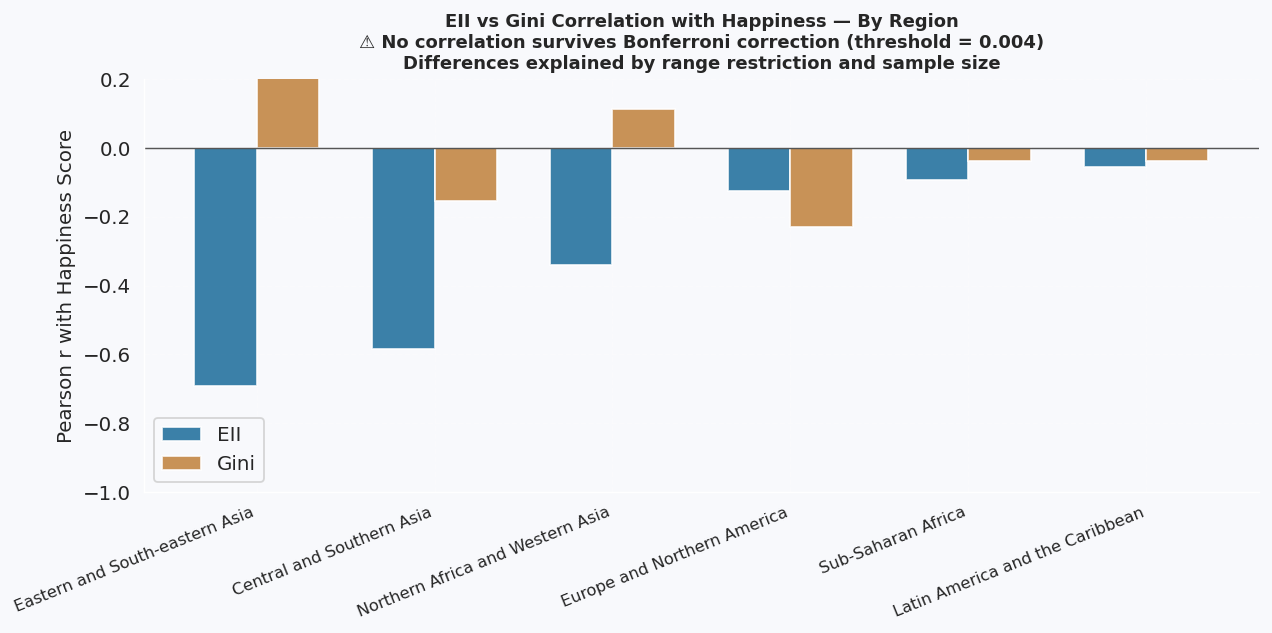

In [79]:
# ── Regional correlation comparison chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['bg'])

x_pos = np.arange(len(region_df))
width = 0.35

bars1 = ax.bar(x_pos - width/2, region_df['r_EII'],  width, label='EII',  color=PALETTE['edu'],    alpha=0.85)
bars2 = ax.bar(x_pos + width/2, region_df['r_Gini'], width, label='Gini', color=PALETTE['income'],  alpha=0.85)

ax.axhline(0, color='#555', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(region_df['Region'], rotation=22, ha='right', fontsize=9)
ax.set_ylabel('Pearson r with Happiness Score', fontsize=11)
ax.set_title('EII vs Gini Correlation with Happiness — By Region\n'
             '⚠ No correlation survives Bonferroni correction (threshold = 0.004)\n'
             'Differences explained by range restriction and sample size',
             fontweight='bold', fontsize=10)
ax.legend()
ax.set_ylim(-1, 0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig_regional_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Regional Analysis

**Important caveat:** With 12 simultaneous tests (6 regions × 2 
predictors), the Bonferroni-corrected threshold is p < 0.004. 
No regional correlation survives this correction — including 
Eastern Asia (p = 0.027).

Regional correlations should therefore be treated as 
**exploratory and descriptive**, not confirmatory.

**Why correlations differ across regions — range restriction:**

The variation in regional correlations is largely explained by 
how much EII varies within each region:

- **Europe** (std = 0.058) — almost no EII variance. All 
  countries cluster near zero. Range restriction makes 
  correlation mathematically impossible to detect, even if 
  the true relationship is strong
- **Sub-Saharan Africa** (std = 0.157) — all countries have 
  high EII (range 0.33–1.00). No low-EII comparison group 
  available within the region
- **Eastern Asia** (std = 0.195) — widest relative range, 
  strongest observed correlation (r = −0.692, n=10)
- **Latin America** — moderate variance but the well-documented 
  happiness paradox suppresses the EII–happiness relationship

**Gini shows no significant regional relationship anywhere** — 
consistent with global findings.

**Conclusion:** Regional analysis is underpowered due to small 
within-region samples (n=8–36) and range restriction. The 
global analysis (n=113) is the appropriate level for inference.

## 7. Results Summary & Interpretation

### Key Findings

| Metric | EII (Education) | Gini (Income) | Combined |
|--------|:--------------:|:------------:|:-------:|
| R² | 0.369 | 0.062 | 0.371 |
| Adj. R² | 0.364 | 0.053 | 0.360 |
| Predictor significant in joint model? | ✅ Yes (p<0.001) | ❌ No (p=0.647) | — |

**Educational inequality accounts for 37% of cross-national variance 
in happiness** — the Gini index accounts for only 6%, and it loses 
statistical significance entirely once educational inequality is 
controlled for. The Gini coefficient even flips sign in the joint 
model (+0.007), suggesting no independent negative effect on happiness 
beyond what it shares with educational inequality.

The constrained Random Forest (CV R² = 0.357 ± 0.040) confirms the 
OLS finding under non-linear assumptions, with EII permutation 
importance 9.5× larger than Gini (0.758 vs 0.080).

Results are robust across three sensitivity checks:
- Excluding 4 influential observations (n=109): EII R² increases to 0.431
- Reliable Gini countries only (n=82): EII R² increases to 0.390
- Both checks: Gini remains non-significant as independent predictor

### Why Might This Be?

**1. Access to opportunity**  
Educational disparities constrain social mobility in ways that are 
directly felt — affecting occupational choice, health literacy, and 
civic participation. Wealth and location gaps in schooling (the 
dominant drivers of EII) determine life trajectories from childhood.

**2. Horizontal inequality**  
The EII captures *horizontal* inequalities — gaps between demographic 
groups — which signal fairness failures and erode social trust. Income 
inequality (Gini) measures *vertical* distribution and may feel more 
abstract or legitimate to individuals than educational exclusion.

**3. Legacy effects**  
The dominance of former Soviet states in the lowest-EII group suggests 
historical policy choices have measurable long-run effects on 
educational equality — and potentially on happiness through the social 
mobility and trust channels above.

**4. GDP confounding (unresolved)**  
Wealthier nations tend to have both lower EII and higher happiness. 
Controlling for GDP per capita is the most important extension of 
this analysis.

### Limitations

- **Cross-sectional design** — no causal claim can be made. 
  Reverse causality (happier societies invest more in equitable 
  education) cannot be ruled out without longitudinal data
- **Systematic missingness** — low-income countries are 
  disproportionately missing math indicators, likely 
  underestimating true inequality for the poorest nations
- **Gini data quality** — 42% of countries have fewer than 
  5 years of observations; addressed with most-recent-value 
  approach and reliability sensitivity check
- **Sample reduction** — three-way merge retains only 113 of 
  177 countries; lost countries have slightly higher mean EII 
  (0.396 vs 0.359), introducing conservative bias — true 
  effect likely stronger than reported
- **Country name matching** — ISO 3166-1 alpha-3 codes should 
  replace string matching in future iterations to reduce merge loss
- **PCA captures 49.2% in PC1** — the index does not capture 
  all dimensions of educational inequality; 3 components needed 
  for 80% cumulative variance
- **GDP confounding** — not controlled for in current models; 
  partial correlations controlling for GDP are a necessary 
  next step
- **Range restriction in regional analysis** — prevents 
  meaningful within-region inference; no regional correlation 
  survives Bonferroni correction
- **Latin American happiness paradox** — Nicaragua and Guatemala 
  are influential outliers; results strengthen when excluded, 
  confirming findings are conservative
- **Happiness subjectivity** — Cantril Ladder reflects 
  self-reported well-being with possible cultural response 
  style bias in cross-national comparisons

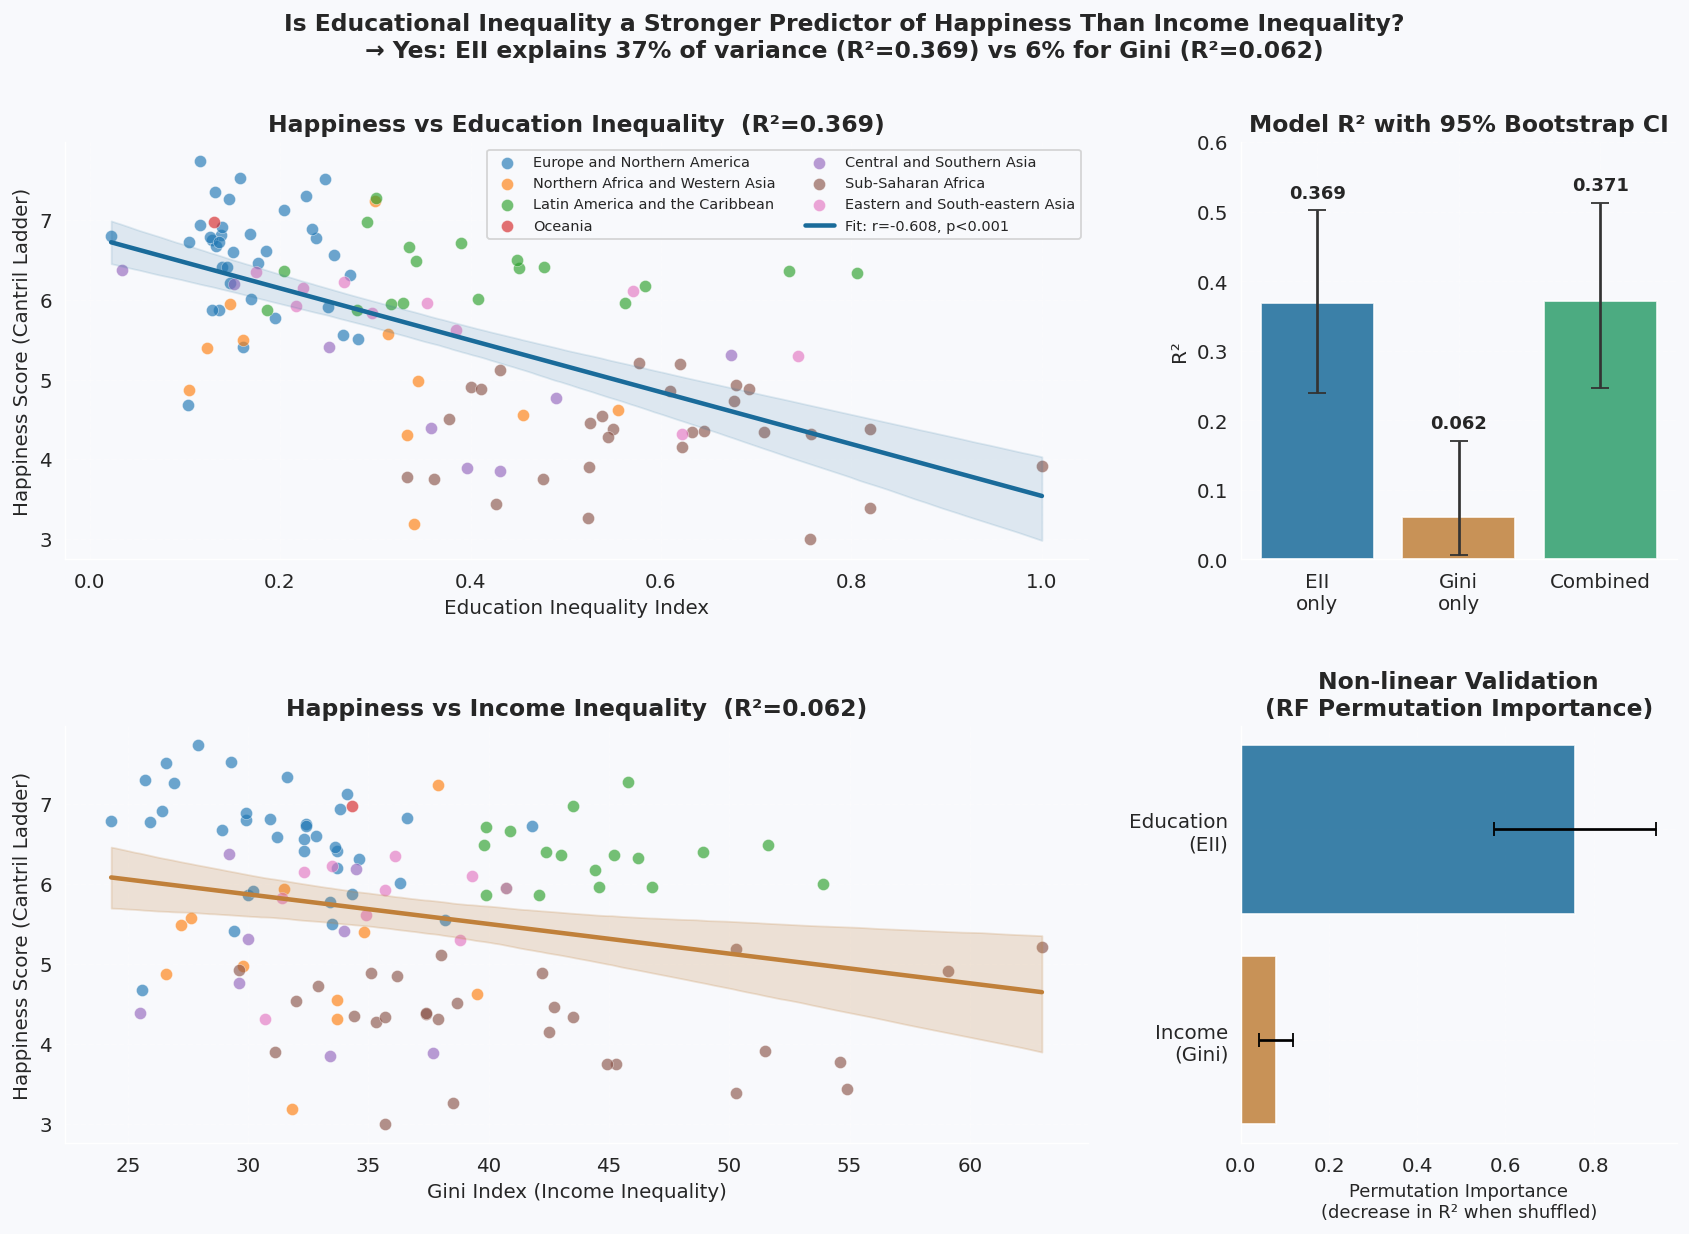


✓ All outputs saved to outputs/


In [82]:
# ── Final summary figure ──────────────────────────────────────────────────────
np.random.seed(42)

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(PALETTE['bg'])
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: Scatter EII vs Happiness ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(PALETTE['bg'])

for reg in df['region_group'].dropna().unique():
    mask = df['region_group'] == reg
    ax1.scatter(df.loc[mask, 'inequality_index'], df.loc[mask, 'happiness_score'],
                alpha=0.65, s=45, edgecolors='white', linewidths=0.3, label=reg)

m1_s, b1_s, r1_s, p1_s, _ = stats.linregress(df['inequality_index'], df['happiness_score'])
xr = np.linspace(df['inequality_index'].min(), df['inequality_index'].max(), 200)
y_line1 = m1_s * xr + b1_s

# Bootstrap CI
x_arr = df['inequality_index'].values
y_arr = df['happiness_score'].values
y_boot1 = np.zeros((2000, 200))
for i in range(2000):
    s = np.random.choice(len(x_arr), len(x_arr), replace=True)
    mb, bb, _, _, _ = stats.linregress(x_arr[s], y_arr[s])
    y_boot1[i] = mb * xr + bb

ax1.fill_between(xr,
                 np.percentile(y_boot1, 2.5,  axis=0),
                 np.percentile(y_boot1, 97.5, axis=0),
                 color=PALETTE['edu'], alpha=0.12)
ax1.plot(xr, y_line1, color=PALETTE['edu'], linewidth=2.5,
         label=f'Fit: r={r1_s:.3f}, p<0.001')

ax1.set_xlabel('Education Inequality Index', fontsize=11)
ax1.set_ylabel('Happiness Score (Cantril Ladder)', fontsize=11)
ax1.set_title(f'Happiness vs Education Inequality  (R²={model1.rsquared:.3f})',
              fontweight='bold')
ax1.legend(fontsize=8, ncol=2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2: R² comparison ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(PALETTE['bg'])

r2_vals  = [model1.rsquared, model2.rsquared, model3.rsquared]
labels   = ['EII\nonly', 'Gini\nonly', 'Combined']
colors_b = [PALETTE['edu'], PALETTE['income'], PALETTE['happy']]
bars = ax2.bar(labels, r2_vals, color=colors_b, alpha=0.85, edgecolor='white')

# Bootstrap CI error bars
r2_cis = [
    np.percentile(r2_edu,  [2.5, 97.5]),
    np.percentile(r2_gini, [2.5, 97.5]),
    np.percentile(r2_both, [2.5, 97.5]),
]
errs = [[v - ci[0] for v, ci in zip(r2_vals, r2_cis)],
        [ci[1] - v for v, ci in zip(r2_vals, r2_cis)]]
ax2.errorbar(labels, r2_vals, yerr=errs, fmt='none',
             color='#333', capsize=5, linewidth=1.5)

for bar, v, ci in zip(bars, r2_vals, r2_cis):
    ax2.text(bar.get_x() + bar.get_width()/2, ci[1] + 0.012,
             f'{v:.3f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax2.set_ylim(0, 0.60)
ax2.set_ylabel('R²', fontsize=11)
ax2.set_title('Model R² with 95% Bootstrap CI', fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Panel 3: Scatter Gini vs Happiness ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor(PALETTE['bg'])

for reg in df['region_group'].dropna().unique():
    mask = df['region_group'] == reg
    ax3.scatter(df.loc[mask, 'gini_index'], df.loc[mask, 'happiness_score'],
                alpha=0.65, s=45, edgecolors='white', linewidths=0.3)

m2_s, b2_s, r2_s, p2_s, _ = stats.linregress(df['gini_index'], df['happiness_score'])
xg = np.linspace(df['gini_index'].min(), df['gini_index'].max(), 200)
y_line3 = m2_s * xg + b2_s

# Bootstrap CI
x_arr3 = df['gini_index'].values
y_boot3 = np.zeros((2000, 200))
for i in range(2000):
    s = np.random.choice(len(x_arr3), len(x_arr3), replace=True)
    mb, bb, _, _, _ = stats.linregress(x_arr3[s], y_arr[s])
    y_boot3[i] = mb * xg + bb

ax3.fill_between(xg,
                 np.percentile(y_boot3, 2.5,  axis=0),
                 np.percentile(y_boot3, 97.5, axis=0),
                 color=PALETTE['income'], alpha=0.20)
ax3.plot(xg, y_line3, color=PALETTE['income'], linewidth=2.5)

ax3.set_xlabel('Gini Index (Income Inequality)', fontsize=11)
ax3.set_ylabel('Happiness Score (Cantril Ladder)', fontsize=11)
ax3.set_title(f'Happiness vs Income Inequality  (R²={model2.rsquared:.3f})',
              fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Panel 4: RF permutation importance ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor(PALETTE['bg'])

ax4.barh(['Income\n(Gini)', 'Education\n(EII)'],
         [perm_imp.importances_mean[1], perm_imp.importances_mean[0]],
         xerr=[perm_imp.importances_std[1] * 2, perm_imp.importances_std[0] * 2],
         color=[PALETTE['income'], PALETTE['edu']],
         alpha=0.85, edgecolor='white',
         error_kw={'linewidth': 1.5, 'color': '#333', 'capsize': 4})

ax4.set_xlabel('Permutation Importance\n(decrease in R² when shuffled)', fontsize=10)
ax4.set_title('Non-linear Validation\n(RF Permutation Importance)', fontweight='bold')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Suptitle & save ───────────────────────────────────────────────────────────
fig.suptitle(
    'Is Educational Inequality a Stronger Predictor of Happiness Than Income Inequality?\n'
    '→ Yes: EII explains 37% of variance (R²=0.369) vs 6% for Gini (R²=0.062)',
    fontsize=13, fontweight='bold'
)

plt.savefig('outputs/fig_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ All outputs saved to outputs/')

---
## 8. Export Final Dataset

In [83]:
df.to_csv('outputs/final_dataset.csv', index=False)
print(f'Saved {len(df)} rows to outputs/final_dataset.csv')
df.describe().round(3)

Saved 113 rows to outputs/final_dataset.csv


,inequality_index,gini_index,gini_mean,gini_year,years_available,happiness_score
count,113.000,113.000,113.000,113.000,113.000,113.000
mean,0.359,36.605,38.104,2020.168,12.876,5.628
std,0.213,7.661,8.141,3.349,8.532,1.143
min,0.023,24.300,25.238,2005.000,1.000,2.998
25%,0.168,31.400,32.300,2019.000,4.000,4.680
50%,0.316,34.600,36.255,2021.000,13.000,5.877
75%,0.524,40.700,43.050,2022.000,21.000,6.494
max,1.000,63.000,62.400,2024.000,25.000,7.736
